In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/TFG/Data_prueba'

In [ ]:
df_min= pd.read_csv(path+'/mfxi1min.txt')
print(df_min.head())

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <VOL>  \
0     MFXI     I      19930104  110300    2315    2315   2315     2315      5   
1     MFXI     I      19930104  110400    2325    2327   2325     2327    100   
2     MFXI     I      19930104  110500    2328    2329   2328     2329    250   
3     MFXI     I      19930104  110700    2329    2329   2329     2329    125   
4     MFXI     I      19930104  110800    2330    2335   2330     2335    200   

   <OPENINT>  
0          0  
1          0  
2          0  
3          0  
4          0  


In [ ]:
from datetime import time

df_min['date_str'] = df_min['<DTYYYYMMDD>'].astype(str)
df_min['time_str'] = df_min['<TIME>'].astype(str).str.zfill(6)

# Crear datetime
df_min['datetime'] = pd.to_datetime(
    df_min['date_str'] + df_min['time_str'],
    format='%Y%m%d%H%M%S'
)
df_min['datetime'] = pd.to_datetime(df_min['datetime'])
df_min['date'] = df_min['datetime'].dt.normalize()
df_min['time'] = df_min['datetime'].dt.time

df_open_mins = df_min[
    (df_min['time'] >= time(9, 00)) &
    (df_min['time'] <= time(9, 14))
].copy()
df_open_mins = (
    df_open_mins
    .sort_values(['date', 'datetime'])
    .assign(min_id=lambda x: x.groupby('date').cumcount() + 1)
)
df_open_mins = df_open_mins.rename(columns={
    '<OPEN>': 'OPEN',
    '<HIGH>': 'HIGH',
    '<LOW>': 'LOW',
    '<CLOSE>': 'CLOSE',
    '<VOL>': 'VOL',
    '<OPENINT>': 'OPENINT'
})
df_open_mins.head()

,<TICKER>,<PER>,<DTYYYYMMDD>,<TIME>,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,date_str,time_str,datetime,date,time,min_id
549237,MFXI,I,20000118,90100,11314,11314,11275,11285,504,0,20000118,090100,2000-01-18 09:01:00,2000-01-18,09:01:00,1
549238,MFXI,I,20000118,90200,11294,11300,11284,11285,72,0,20000118,090200,2000-01-18 09:02:00,2000-01-18,09:02:00,2
549239,MFXI,I,20000118,90300,11280,11290,11272,11275,413,0,20000118,090300,2000-01-18 09:03:00,2000-01-18,09:03:00,3
549240,MFXI,I,20000118,90400,11274,11280,11272,11280,42,0,20000118,090400,2000-01-18 09:04:00,2000-01-18,09:04:00,4
549241,MFXI,I,20000118,90500,11283,11290,11281,11290,47,0,20000118,090500,2000-01-18 09:05:00,2000-01-18,09:05:00,5


In [ ]:
#Pivotar para tener formato diario
cols = [
    'date', 'min_id',
    'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL', 'OPENINT'
]
df_open_mins = df_open_mins[cols]
df_pivot = df_open_mins.pivot(
    index='date',
    columns='min_id',
    values=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
)

# Aplanar columnas
df_pivot.columns = [
    f"m{min_id}_{var.lower()}"
    for var, min_id in df_pivot.columns
]

df_pivot = df_pivot.reset_index()
df_pivot

,date,m1_open,m2_open,m3_open,m4_open,m5_open,m6_open,m7_open,m8_open,m9_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,2000-01-18,11314.0,11294.0,11280.0,11274.0,11283.0,11285.0,11290.0,11293.0,11270.0,...,26.0,59.0,81.0,132.0,63.0,22.0,19.0,10.0,28.0,NaN
1,2000-01-19,11000.0,11026.0,11005.0,11006.0,11014.0,11025.0,11026.0,11031.0,11030.0,...,89.0,69.0,17.0,23.0,34.0,38.0,41.0,21.0,242.0,NaN
2,2000-01-20,11180.0,11180.0,11197.0,11195.0,11189.0,11190.0,11205.0,11218.0,11224.0,...,89.0,61.0,49.0,217.0,87.0,78.0,65.0,34.0,4.0,NaN
3,2000-01-21,10960.0,10931.0,10941.0,10948.0,10946.0,10950.0,10946.0,10941.0,10942.0,...,35.0,130.0,20.0,49.0,111.0,27.0,18.0,23.0,99.0,NaN
4,2000-01-24,10985.0,10975.0,10989.0,10995.0,10995.0,11004.0,11014.0,11003.0,NaN,...,34.0,20.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6599,2026-01-12,17533.0,17545.0,17523.0,17504.0,17535.0,17525.0,17522.0,17522.0,17517.0,...,33.0,27.0,28.0,44.0,27.0,31.0,33.0,19.0,34.0,23.0
6600,2026-01-13,17713.0,17721.0,17703.0,17711.0,17727.0,17719.0,17729.0,17724.0,17726.0,...,23.0,16.0,16.0,21.0,17.0,23.0,30.0,25.0,11.0,19.0
6601,2026-01-14,17734.0,17754.0,17766.0,17762.0,17774.0,17785.0,17781.0,17779.0,17769.0,...,10.0,12.0,15.0,10.0,12.0,13.0,17.0,11.0,10.0,18.0
6602,2026-01-15,17720.0,17699.0,17682.0,17689.0,17684.0,17672.0,17650.0,17638.0,17638.0,...,13.0,31.0,14.0,24.0,13.0,13.0,10.0,12.0,13.0,11.0


In [ ]:
df_min['date_str'] = df_min['<DTYYYYMMDD>'].astype(str)
df_min['time_str'] = df_min['<TIME>'].astype(str).str.zfill(6)
df_min['datetime'] = pd.to_datetime(
    df_min['date_str'] + df_min['time_str'], format='%Y%m%d%H%M%S'
)
df_min['date'] = df_min['datetime'].dt.normalize()
df_min['time'] = df_min['datetime'].dt.time

df_min = df_min.rename(columns={
    '<OPEN>': 'OPEN', '<HIGH>': 'HIGH',
    '<LOW>':  'LOW',  '<CLOSE>': 'CLOSE',
    '<VOL>':  'VOL',  '<OPENINT>': 'OPENINT'
})
df_min = df_min.sort_values(['date', 'datetime'])
df_dia = df_min.groupby('date').agg(
    D_OPEN  = ('OPEN',  'first'),
    D_HIGH  = ('HIGH',  'max'),
    D_LOW   = ('LOW',   'min'),
    D_CLOSE = ('CLOSE', 'last'),
    D_VOL   = ('VOL',   'sum')
).reset_index()

In [ ]:
df_final = df_dia.merge(
    df_pivot,
    on='date',
    how='left'
)
df_final.head()

,date,D_OPEN,D_HIGH,D_LOW,D_CLOSE,D_VOL,m1_open,m2_open,m3_open,m4_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,1993-01-04,2315,2349,2315,2349,9955,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-01-05,2370,2416,2370,2408,10804,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-01-07,2409,2414,2384,2405,11752,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-01-08,2400,2419,2400,2415,7315,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-01-11,2410,2430,2386,2389,15769,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols_mins = [col for col in df_final.columns if col.startswith('m')]
df_final['year'] = df_final['date'].dt.year
nan_summary = df_final.groupby('year').apply(
    lambda x: pd.Series({
        'total_dias': len(x),
        'dias_con_nan': x[cols_mins].isna().any(axis=1).sum(),
        'dias_completos': len(x) - x[cols_mins].isna().any(axis=1).sum()
    })
).reset_index()

print(nan_summary)

    year  total_dias  dias_con_nan  dias_completos
0   1993         247           247               0
1   1994         244           244               0
2   1995         245           245               0
3   1996         250           250               0
4   1997         248           248               0
5   1998         248           248               0
6   1999         250           250               0
7   2000         249           249               0
8   2001         250           250               0
9   2002         250           250               0
10  2003         250           244               6
11  2004         251           250               1
12  2005         256           256               0
13  2006         254           254               0
14  2007         253           253               0
15  2008         254           254               0
16  2009         254           254               0
17  2010         256           256               0
18  2011         257           

/tmp/ipykernel_2404/3739915113.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_summary = df_final.groupby('year').apply(


No todos los años cuentan con valores de minutos. No podemos eliminar directamente los NaN porque entonces nos quedaríamos con pocos datos y sería poca muestra. Vamos a utilizar la siguiente estrategia:

Para los modelos que soportan NaN-> mantener. Se va a mantener los Nan para modelos como XGBoost porque lo pueden soportar y así comprobamos.
Para los modelos que no lo soportan -> Se reemplazará por la mediana. En caso de no obtener buenos resultados también se va a probar a eliminar las filas que tienen NaN.

# Cáclculo de parámetros

## Diario:

 displ= ((high+low)/2)- open  Para el día. Para ello guardamos los máximos, mínimos y de apertura en vectoeres.

In [ ]:
high = df_final['D_HIGH']
low = df_final['D_LOW']
open_ = df_final['D_OPEN']
close = df_final['D_CLOSE']
vol = df_final['D_VOL']

df_final['DISPLAY'] = ((high + low) / 2) - open_

Ahora se va a determinar BULLISH (es un valor que depende de displ, en caso de que displ sea positivo implica que es verdadero, si es falso es que es negativo)

In [ ]:
df_final['BULLISH'] = df_final['DISPLAY'] > 0

Definición del set de predictor en base a días anteriores:

1. El vactor de características incorporará variables que se corresponden con los 5 días anteriores. (Cómo la media o varianza).
2. Así mismo también incorporará variables del intervalo tomado al principio del día.

Variables:

- p5_close_open, p4_close_open, p3_close_open, p2_close_open, p1_close_open. Se corresponderán conn los vectores de características, p5 indica que es de 5 días antes, p4 de cuatro día antes... Se corresponde con el valor de cierre menos el valor de apertura.
- La media y la desviación típica de estos 5 valores en los días anteriores se incorpora también (p_close_open_mean y p_close_open_sd)

In [ ]:
df_final['CLOSE_OPEN'] = close - open_
for i in range(1, 6):
    df_final[f'p{i}_close_open'] = df_final['CLOSE_OPEN'].shift(i)

df_final['p_close_open_mean'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].mean(axis=1)

df_final['p_close_open_sd'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_high_low'] = high.shift(i) - low.shift(i)

for i in range(1, 6):
    df_final[f'p{i}_is_bullish'] = df_final['BULLISH'].shift(i)

df_final['HINGE'] = (high - low) / 2

for i in range(1, 6):
    df_final[f'p{i}_HINGE'] = df_final['HINGE'].shift(i)

df_final['p_HINGE_mean'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].mean(axis=1)

df_final['p_HINGE_sd'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_volume'] = vol.shift(i)

df_final['p_volume_mean'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].mean(axis=1)

df_final['p_volume_sd'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_display'] = df_final['DISPLAY'].shift(i)

Los gaps representan la diferencia entre el precio de apertura del día y el cierre del día anterior.
Son fundamentales en trading porque condensan mucha información sobre sentimiento del mercado, reacción a noticias, y volatilidad nocturna.

Variables añadidas:

- prev_close → cierre del día anterior

- gap_abs → diferencia OPEN - CLOSE_prev

- gap_pct → tamaño del gap en porcentaje

- gap_dir → 1 si gap alcista, 0 si bajista

- gap_zscore → gap estandarizado (compara el gap actual con los últimos 20 días)

In [ ]:
# Cierre del día previo
df_final['prev_close'] = df_final['D_CLOSE'].shift(1)

# Gap absoluto: mide si el mercado abre por encima o por debajo del cierre previo
df_final['gap_abs'] = df_final['D_OPEN'] - df_final['prev_close']

# Gap porcentual: gap relativo al precio
df_final['gap_pct'] = df_final['gap_abs'] / df_final['prev_close']

# Dirección del gap: 1 si es alcista, 0 si es bajista
df_final['gap_dir'] = (df_final['gap_abs'] > 0).astype(int)

# Gap Z-score: gap actual comparado con su media y desviación de 20 días
df_final['gap_zscore'] = (
    df_final['gap_pct'] - df_final['gap_pct'].rolling(20).mean()
) / df_final['gap_pct'].rolling(20).std()

# Gaps de días anteriores (últimos 5 días)
for i in range(1, 6):
    df_final[f'p{i}_gap_abs'] = df_final['gap_abs'].shift(i)
    df_final[f'p{i}_gap_pct'] = df_final['gap_pct'].shift(i)
    df_final[f'p{i}_gap_dir'] = df_final['gap_dir'].shift(i)
    df_final[f'p{i}_gap_zscore'] = df_final['gap_zscore'].shift(i)


El True Range mide la volatilidad real del día considerando el rango de precios y los gaps.
El ATR (Average True Range) suaviza esa volatilidad en el tiempo.

Variables añadidas:

- true_range → volatilidad real del día

- ATR_5, ATR_10 → volatilidad reciente y suavizada

- ATR_zscore → volatilidad anormalmente alta o baja

In [ ]:
import numpy as np

# High y Low del día previo
df_final['prev_high'] = df_final['D_HIGH'].shift(1)
df_final['prev_low'] = df_final['D_LOW'].shift(1)

# True Range: máxima distancia relevante del día
tr1 = df_final['D_HIGH'] - df_final['D_LOW']
tr2 = (df_final['D_HIGH'] - df_final['prev_close']).abs()
tr3 = (df_final['D_LOW'] - df_final['prev_close']).abs()
df_final['true_range'] = np.maximum.reduce([tr1, tr2, tr3])

# ATR a 5 y 10 días
df_final['ATR_5'] = df_final['true_range'].rolling(5).mean()
df_final['ATR_10'] = df_final['true_range'].rolling(10).mean()

# ATR Z-score: volatilidad actual comparada con 20 días
df_final['ATR_zscore'] = (
    df_final['ATR_5'] - df_final['ATR_5'].rolling(20).mean()
) / df_final['ATR_5'].rolling(20).std()

for i in range(1, 6):
    # TR de hace i días
    df_final[f'lag{i}_true_range'] = df_final['true_range'].shift(i)

    # ATR de hace i días
    df_final[f'lag{i}_ATR_5'] = df_final['ATR_5'].shift(i)
    df_final[f'lag{i}_ATR_10'] = df_final['ATR_10'].shift(i)

    # ATR z-score de hace i días
    df_final[f'lag{i}_ATR_zscore'] = df_final['ATR_zscore'].shift(i)


Estas variables capturan si la volatilidad está expandiendo o contrayendo, y si hay tendencia reciente.

Variables añadidas:

- vol_regime → ATR_5 / ATR_10

- MA5, MA20 → medias móviles

- trend_MA_cross → cruce de medias (tendencia alcista =1)

In [ ]:
# Régimen de volatilidad: expansión (>1) o contracción (<1)
df_final['vol_regime'] = df_final['ATR_5'] / df_final['ATR_10']

# Medias móviles simple
df_final['MA5'] = df_final['D_CLOSE'].rolling(5).mean()
df_final['MA20'] = df_final['D_CLOSE'].rolling(20).mean()

# Señal de tendencia basada en cruce de medias
df_final['trend_MA_cross'] = (df_final['MA5'] > df_final['MA20']).astype(int)

# Lags de 5 días (solo información previa)
for i in range(1, 6):
    df_final[f'lag{i}_vol_regime'] = df_final['vol_regime'].shift(i)
    df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
    df_final[f'lag{i}_MA20'] = df_final['MA20'].shift(i)
    df_final[f'lag{i}_trend_MA_cross'] = df_final['trend_MA_cross'].shift(i)
df_final['log_ret'] = np.log(df_final['D_CLOSE'] / df_final['D_OPEN'])

/tmp/ipykernel_2404/1082626466.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
/tmp/ipykernel_2404/1082626466.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_MA20'] = df_final['MA20'].shift(i)
/tmp/ipykernel_2404/1082626466.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

## Minutos

In [ ]:
open_cols  = [f'm{i}_open' for i in range(1, 16)]
close_cols = [f'm{i}_close' for i in range(1, 16)]
high_cols  = [f'm{i}_high' for i in range(1, 16)]
low_cols   = [f'm{i}_low' for i in range(1, 16)]
vol_cols   = [f'm{i}_vol' for i in range(1, 16)]
df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)


# Precio apertura primer minuto y cierre último minuto
df_final['open_15m'] = df_final['m1_open']
df_final['close_15m'] = df_final['m15_close']
# Retorno logarítmico primeros 15 minutos
df_final['log_ret_15m'] = np.log(
    df_final['close_15m'] / df_final['open_15m']
)
# Rango de precios en los primeros 15 minutos
df_final['range_15m'] = (
    df_final[high_cols].max(axis=1) -
    df_final[low_cols].min(axis=1)
)
# Dirección del movimiento
df_final['dir_15m'] = np.sign(df_final['log_ret_15m'])


/tmp/ipykernel_2404/1670737474.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
/tmp/ipykernel_2404/1670737474.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)
/tmp/ipykernel_2404/1670737474.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

# Modelado

Vale, en primer lugar toca establecer probabilidades:

In [ ]:
#Primero de todo vamos a ordenar cronológicamente (just in case)
df_final = df_final.sort_values('date')


In [ ]:
df_model = df_final.copy()
df_model['y'] = (df_final['log_ret'] > 0).astype(int)

df_model.columns.to_list()

['date',
 'D_OPEN',
 'D_HIGH',
 'D_LOW',
 'D_CLOSE',
 'D_VOL',
 'm1_open',
 'm2_open',
 'm3_open',
 'm4_open',
 'm5_open',
 'm6_open',
 'm7_open',
 'm8_open',
 'm9_open',
 'm10_open',
 'm11_open',
 'm12_open',
 'm13_open',
 'm14_open',
 'm15_open',
 'm1_high',
 'm2_high',
 'm3_high',
 'm4_high',
 'm5_high',
 'm6_high',
 'm7_high',
 'm8_high',
 'm9_high',
 'm10_high',
 'm11_high',
 'm12_high',
 'm13_high',
 'm14_high',
 'm15_high',
 'm1_low',
 'm2_low',
 'm3_low',
 'm4_low',
 'm5_low',
 'm6_low',
 'm7_low',
 'm8_low',
 'm9_low',
 'm10_low',
 'm11_low',
 'm12_low',
 'm13_low',
 'm14_low',
 'm15_low',
 'm1_close',
 'm2_close',
 'm3_close',
 'm4_close',
 'm5_close',
 'm6_close',
 'm7_close',
 'm8_close',
 'm9_close',
 'm10_close',
 'm11_close',
 'm12_close',
 'm13_close',
 'm14_close',
 'm15_close',
 'm1_vol',
 'm2_vol',
 'm3_vol',
 'm4_vol',
 'm5_vol',
 'm6_vol',
 'm7_vol',
 'm8_vol',
 'm9_vol',
 'm10_vol',
 'm11_vol',
 'm12_vol',
 'm13_vol',
 'm14_vol',
 'm15_vol',
 'year',
 'DISPLAY',
 

In [ ]:
cols_future = [
    'D_HIGH', 'D_LOW', 'D_CLOSE', 'D_VOL', 'D_OPENINT',
    'DISPLAY', 'BULLISH', 'CLOSE_OPEN',
    'HINGE',
    'true_range',
    'ATR_5', 'ATR_10', 'ATR_zscore',
    'vol_regime',
    'MA5', 'MA20',
    'trend_MA_cross',
    'prev_high', 'prev_low',
    'log_ret'
]

df_model = df_model.drop(
    columns=[c for c in cols_future if c in df_model.columns]
)

print("Columnas finales:", len(df_model.columns))
print(df_model.columns.to_list())


Columnas finales: 187
['date', 'D_OPEN', 'm1_open', 'm2_open', 'm3_open', 'm4_open', 'm5_open', 'm6_open', 'm7_open', 'm8_open', 'm9_open', 'm10_open', 'm11_open', 'm12_open', 'm13_open', 'm14_open', 'm15_open', 'm1_high', 'm2_high', 'm3_high', 'm4_high', 'm5_high', 'm6_high', 'm7_high', 'm8_high', 'm9_high', 'm10_high', 'm11_high', 'm12_high', 'm13_high', 'm14_high', 'm15_high', 'm1_low', 'm2_low', 'm3_low', 'm4_low', 'm5_low', 'm6_low', 'm7_low', 'm8_low', 'm9_low', 'm10_low', 'm11_low', 'm12_low', 'm13_low', 'm14_low', 'm15_low', 'm1_close', 'm2_close', 'm3_close', 'm4_close', 'm5_close', 'm6_close', 'm7_close', 'm8_close', 'm9_close', 'm10_close', 'm11_close', 'm12_close', 'm13_close', 'm14_close', 'm15_close', 'm1_vol', 'm2_vol', 'm3_vol', 'm4_vol', 'm5_vol', 'm6_vol', 'm7_vol', 'm8_vol', 'm9_vol', 'm10_vol', 'm11_vol', 'm12_vol', 'm13_vol', 'm14_vol', 'm15_vol', 'year', 'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open', 'p_close_open_mean', 'p_cl

In [ ]:
#Vale, empezamos con la parte de programar el modelo en base a probabilidades. Primer paso va a ser intentarlo con regresión logística. ç
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report
import numpy as np
import pandas as pd

# Eliminar filas con NaN
df_model = df_model.dropna().copy()
print(df_model.columns.to_list())

# Separar X e y
X = df_model.drop(columns=['y', 'date'])
y = df_model['y']
print(X.columns.to_list())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model.fit(X_train_scaled, y_train)

probs = model.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de clase 1 (subida)
threshold_up = 0.7
threshold_down = 0.4

def label_from_prob(p):
    if p >= threshold_up:
        return 1   # subida
    elif p <= threshold_down:
        return 0   # bajada
    else:
        return -1  # neutral / no hacer nada

pred_labels = np.array([label_from_prob(p) for p in probs])

df_results = pd.DataFrame({
    'y_true': y_test,
    'prob_up': probs,
    'pred_label': pred_labels
})

print(df_results['pred_label'].value_counts())
df_results.head()

['date', 'D_OPEN', 'm1_open', 'm2_open', 'm3_open', 'm4_open', 'm5_open', 'm6_open', 'm7_open', 'm8_open', 'm9_open', 'm10_open', 'm11_open', 'm12_open', 'm13_open', 'm14_open', 'm15_open', 'm1_high', 'm2_high', 'm3_high', 'm4_high', 'm5_high', 'm6_high', 'm7_high', 'm8_high', 'm9_high', 'm10_high', 'm11_high', 'm12_high', 'm13_high', 'm14_high', 'm15_high', 'm1_low', 'm2_low', 'm3_low', 'm4_low', 'm5_low', 'm6_low', 'm7_low', 'm8_low', 'm9_low', 'm10_low', 'm11_low', 'm12_low', 'm13_low', 'm14_low', 'm15_low', 'm1_close', 'm2_close', 'm3_close', 'm4_close', 'm5_close', 'm6_close', 'm7_close', 'm8_close', 'm9_close', 'm10_close', 'm11_close', 'm12_close', 'm13_close', 'm14_close', 'm15_close', 'm1_vol', 'm2_vol', 'm3_vol', 'm4_vol', 'm5_vol', 'm6_vol', 'm7_vol', 'm8_vol', 'm9_vol', 'm10_vol', 'm11_vol', 'm12_vol', 'm13_vol', 'm14_vol', 'm15_vol', 'year', 'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open', 'p_close_open_mean', 'p_close_open_sd', 'p1_high

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,y_true,prob_up,pred_label
7892,1,0.580928,-1
7893,1,0.666545,-1
7894,1,0.692874,-1
7895,1,0.611131,-1
7896,1,0.784951,1


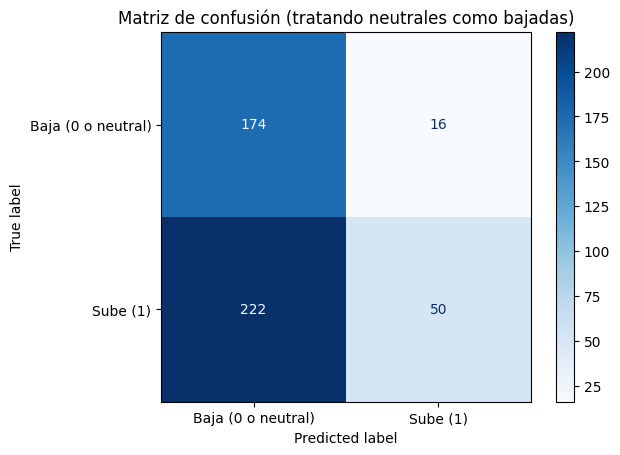

Reporte de clasificación (tratando neutrales como bajadas):
                  precision    recall  f1-score   support

Baja (0/neutral)       0.44      0.92      0.59       190
        Sube (1)       0.76      0.18      0.30       272

        accuracy                           0.48       462
       macro avg       0.60      0.55      0.44       462
    weighted avg       0.63      0.48      0.42       462


Reporte solo con predicciones claras (sin neutrales):
              precision    recall  f1-score   support

    Baja (0)       0.55      0.84      0.67        97
    Sube (1)       0.76      0.43      0.55       115

    accuracy                           0.62       212
   macro avg       0.66      0.63      0.61       212
weighted avg       0.66      0.62      0.60       212



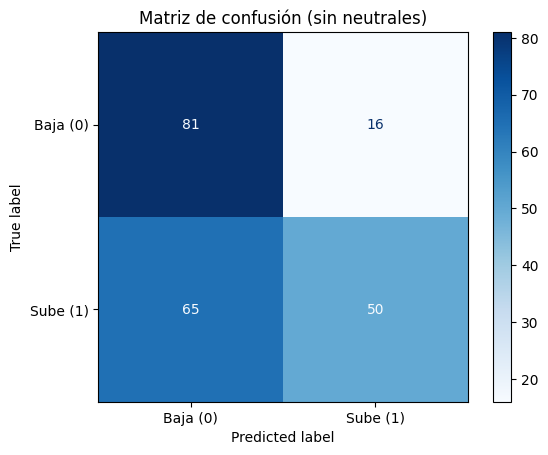

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, np.where(pred_labels==-1, 0, pred_labels))  # -1 se trata como 0 para matriz
disp = ConfusionMatrixDisplay(cm, display_labels=['Baja (0 o neutral)', 'Sube (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (tratando neutrales como bajadas)")
plt.show()

print("Reporte de clasificación (tratando neutrales como bajadas):")
print(classification_report(y_test, np.where(pred_labels==-1, 0, pred_labels), target_names=['Baja (0/neutral)', 'Sube (1)']))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, np.where(pred_labels==-1, 0, pred_labels))  # -1 se trata como 0 para matriz
disp = ConfusionMatrixDisplay(cm, display_labels=['Baja (0 o neutral)', 'Sube (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (tratando neutrales como bajadas)")
plt.show()

print("Reporte de clasificación (tratando neutrales como bajadas):")
print(classification_report(y_test, np.where(pred_labels==-1, 0, pred_labels), target_names=['Baja (0/neutral)', 'Sube (1)']))

# Evaluación sin clase neutral
mask = pred_labels != -1
y_true_eval = y_test[mask]
y_pred_eval = pred_labels[mask]

print("\nReporte solo con predicciones claras (sin neutrales):")
print(classification_report(y_true_eval, y_pred_eval, target_names=['Baja (0)', 'Sube (1)']))

# Matriz de confusión sin neutrales
cm_clear = confusion_matrix(y_true_eval, y_pred_eval)
disp_clear = ConfusionMatrixDisplay(cm_clear, display_labels=['Baja (0)', 'Sube (1)'])
disp_clear.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (sin neutrales)")
plt.show()

# --- Evaluación sin clase neutral ---
mask = pred_labels != -1
y_true_eval = y_test[mask]
y_pred_eval = pred_labels[mask]

print("\nReporte solo con predicciones claras (sin neutrales):")
print(classification_report(y_true_eval, y_pred_eval, target_names=['Baja (0)', 'Sube (1)']))

# Matriz de confusión sin neutrales
cm_clear = confusion_matrix(y_true_eval, y_pred_eval)
disp_clear = ConfusionMatrixDisplay(cm_clear, display_labels=['Baja (0)', 'Sube (1)'])
disp_clear.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (sin neutrales)")
plt.show()


=== UMBRALES MAE (Stop-Loss sugerido) ===
  P25 (stop ajustado):  -83.25 puntos
  P50 (stop moderado):  -39.00 puntos
  P75 (stop amplio):    -14.00 puntos

=== UMBRALES MFE (Take-Profit sugerido) ===
  P25 (target conservador): 65.75 puntos
  P50 (target moderado):    108.50 puntos
  P75 (target ambicioso):   164.50 puntos


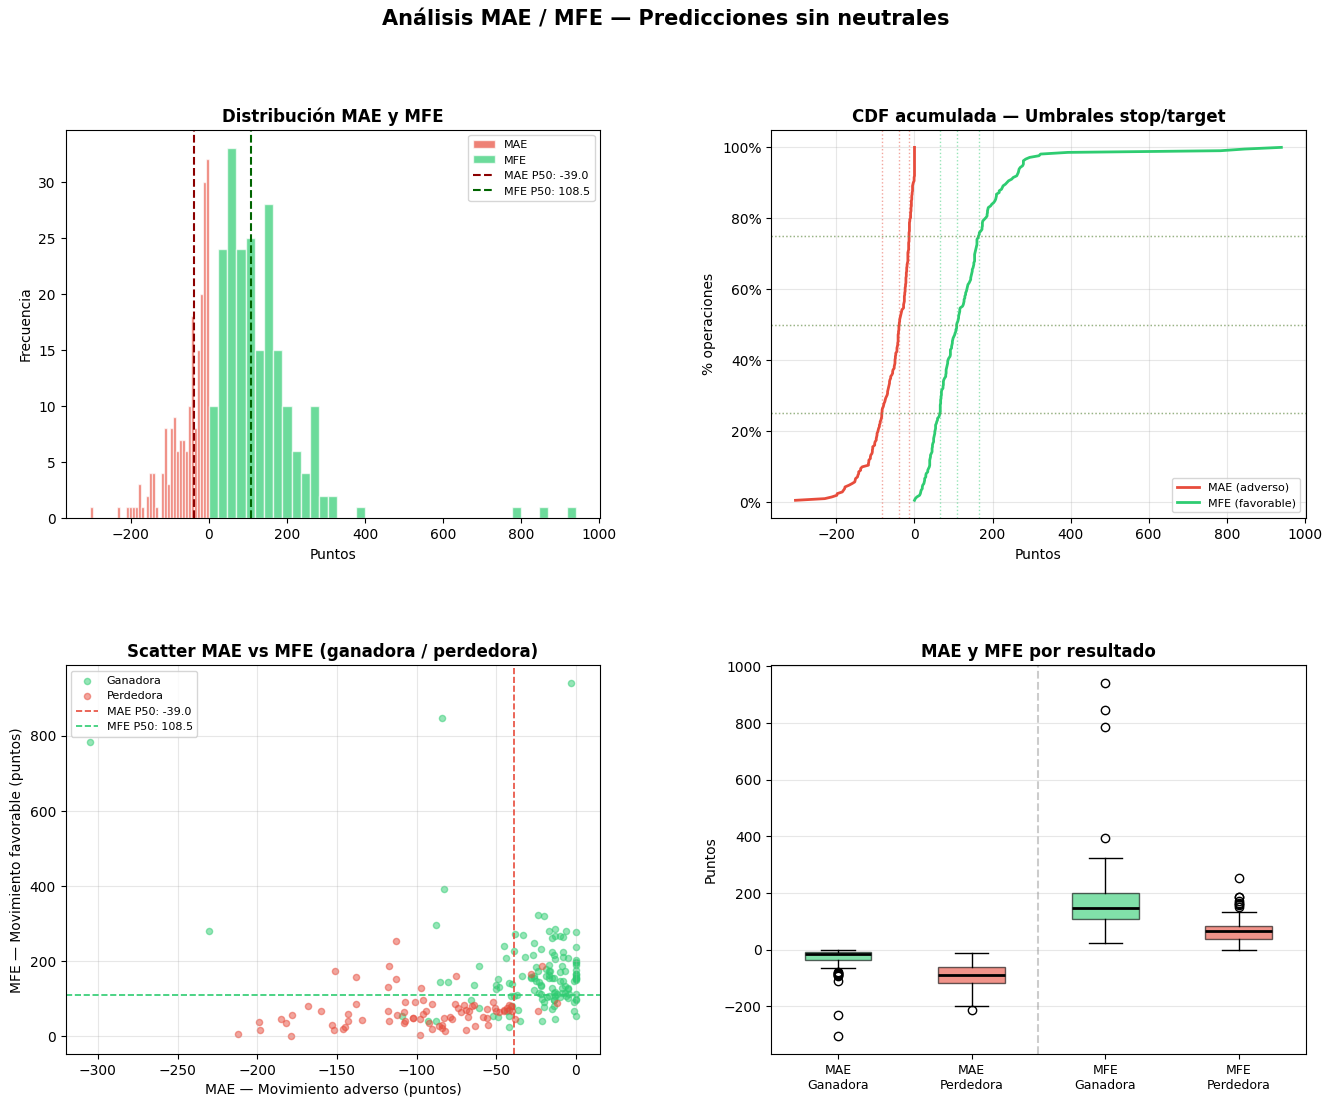

Gráfica guardada como 'mae_mfe_analysis.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Solo predicciones claras (sin neutrales)
mask = pred_labels != -1
df_eval = df_results[mask].copy()

# Recuperar columnas de precio alineadas con el test set
df_prices = df_final.loc[y_test.index, ['D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']]
df_eval = df_eval.join(df_prices)

# Dirección de la operación según predicción
df_eval['direction'] = df_eval['pred_label'].map({1: 'long', 0: 'short'})

# MAE: movimiento máximo en contra (siempre negativo o cero)
df_eval['MAE'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_LOW']  - df_eval['D_OPEN'],   # largo: baja duele
    df_eval['D_OPEN'] - df_eval['D_HIGH']    # corto: sube duele
)

# MFE: movimiento máximo a favor (siempre positivo o cero)
df_eval['MFE'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_HIGH'] - df_eval['D_OPEN'],   # largo: sube beneficia
    df_eval['D_OPEN'] - df_eval['D_LOW']     # corto: baja beneficia
)

# Resultado final al cierre
df_eval['result'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_CLOSE'] - df_eval['D_OPEN'],
    df_eval['D_OPEN']  - df_eval['D_CLOSE']
)

df_eval['outcome'] = np.where(df_eval['result'] > 0, 'Ganadora', 'Perdedora')

¡

mae_p25 = np.percentile(df_eval['MAE'], 25)   # stop ajustado
mae_p50 = np.percentile(df_eval['MAE'], 50)   # stop moderado
mae_p75 = np.percentile(df_eval['MAE'], 75)   # stop amplio

mfe_p25 = np.percentile(df_eval['MFE'], 25)
mfe_p50 = np.percentile(df_eval['MFE'], 50)
mfe_p75 = np.percentile(df_eval['MFE'], 75)

print("=== UMBRALES MAE (Stop-Loss sugerido) ===")
print(f"  P25 (stop ajustado):  {mae_p25:.2f} puntos")
print(f"  P50 (stop moderado):  {mae_p50:.2f} puntos")
print(f"  P75 (stop amplio):    {mae_p75:.2f} puntos")

print("\n=== UMBRALES MFE (Take-Profit sugerido) ===")
print(f"  P25 (target conservador): {mfe_p25:.2f} puntos")
print(f"  P50 (target moderado):    {mfe_p50:.2f} puntos")
print(f"  P75 (target ambicioso):   {mfe_p75:.2f} puntos")


fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis MAE / MFE — Predicciones sin neutrales', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

colors = {'Ganadora': '#2ecc71', 'Perdedora': '#e74c3c'}

# Gráfica 1: Histogramas MAE y MFE
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_eval['MAE'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white', label='MAE')
ax1.hist(df_eval['MFE'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white', label='MFE')
ax1.axvline(mae_p50, color='darkred',   linestyle='--', lw=1.5, label=f'MAE P50: {mae_p50:.1f}')
ax1.axvline(mfe_p50, color='darkgreen', linestyle='--', lw=1.5, label=f'MFE P50: {mfe_p50:.1f}')
ax1.set_title('Distribución MAE y MFE', fontweight='bold')
ax1.set_xlabel('Puntos')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=8)

#  Gráfica 2: CDF acumulada
ax2 = fig.add_subplot(gs[0, 1])
mae_sorted = np.sort(df_eval['MAE'])
mfe_sorted = np.sort(df_eval['MFE'])
cdf = np.arange(1, len(mae_sorted) + 1) / len(mae_sorted)

ax2.plot(mae_sorted, cdf, color='#e74c3c', lw=2, label='MAE (adverso)')
ax2.plot(mfe_sorted, cdf, color='#2ecc71', lw=2, label='MFE (favorable)')

# Líneas de referencia de percentiles
for p, val in [(0.25, mae_p25), (0.50, mae_p50), (0.75, mae_p75)]:
    ax2.axhline(p, color='#e74c3c', linestyle=':', alpha=0.5, lw=1)
    ax2.axvline(val, color='#e74c3c', linestyle=':', alpha=0.5, lw=1)
for p, val in [(0.25, mfe_p25), (0.50, mfe_p50), (0.75, mfe_p75)]:
    ax2.axhline(p, color='#2ecc71', linestyle=':', alpha=0.5, lw=1)
    ax2.axvline(val, color='#2ecc71', linestyle=':', alpha=0.5, lw=1)

ax2.set_title('CDF acumulada — Umbrales stop/target', fontweight='bold')
ax2.set_xlabel('Puntos')
ax2.set_ylabel('% operaciones')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Gráfica 3: Scatter MAE vs MFE coloreado por resultado
ax3 = fig.add_subplot(gs[1, 0])
for outcome, grp in df_eval.groupby('outcome'):
    ax3.scatter(grp['MAE'], grp['MFE'],
                c=colors[outcome], alpha=0.5, s=20, label=outcome)

ax3.axvline(mae_p50, color='#e74c3c', linestyle='--', lw=1.2, label=f'MAE P50: {mae_p50:.1f}')
ax3.axhline(mfe_p50, color='#2ecc71', linestyle='--', lw=1.2, label=f'MFE P50: {mfe_p50:.1f}')
ax3.set_title('Scatter MAE vs MFE (ganadora / perdedora)', fontweight='bold')
ax3.set_xlabel('MAE — Movimiento adverso (puntos)')
ax3.set_ylabel('MFE — Movimiento favorable (puntos)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Gráfica 4: Box MAE y MFE por resultado
ax4 = fig.add_subplot(gs[1, 1])
data_box = [
    df_eval.loc[df_eval['outcome'] == 'Ganadora', 'MAE'],
    df_eval.loc[df_eval['outcome'] == 'Perdedora', 'MAE'],
    df_eval.loc[df_eval['outcome'] == 'Ganadora', 'MFE'],
    df_eval.loc[df_eval['outcome'] == 'Perdedora', 'MFE'],
]
bp = ax4.boxplot(data_box, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', lw=2))

box_colors = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax4.set_xticks([1, 2, 3, 4])
ax4.set_xticklabels(['MAE\nGanadora', 'MAE\nPerdedora', 'MFE\nGanadora', 'MFE\nPerdedora'], fontsize=9)
ax4.set_title('MAE y MFE por resultado', fontweight='bold')
ax4.set_ylabel('Puntos')
ax4.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('mae_mfe_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'mae_mfe_analysis.png'")

=== RESULTADOS BACKTEST ===
  Operaciones totales:  212
  Ganadoras:            104 (49.1%)
  Perdedoras:           108 (50.9%)
  PnL total:            5673.0 puntos
  PnL medio/operación:  26.8 puntos
  Max Drawdown:         -410.0 puntos
  Ratio beneficio/riesgo real: 2.43


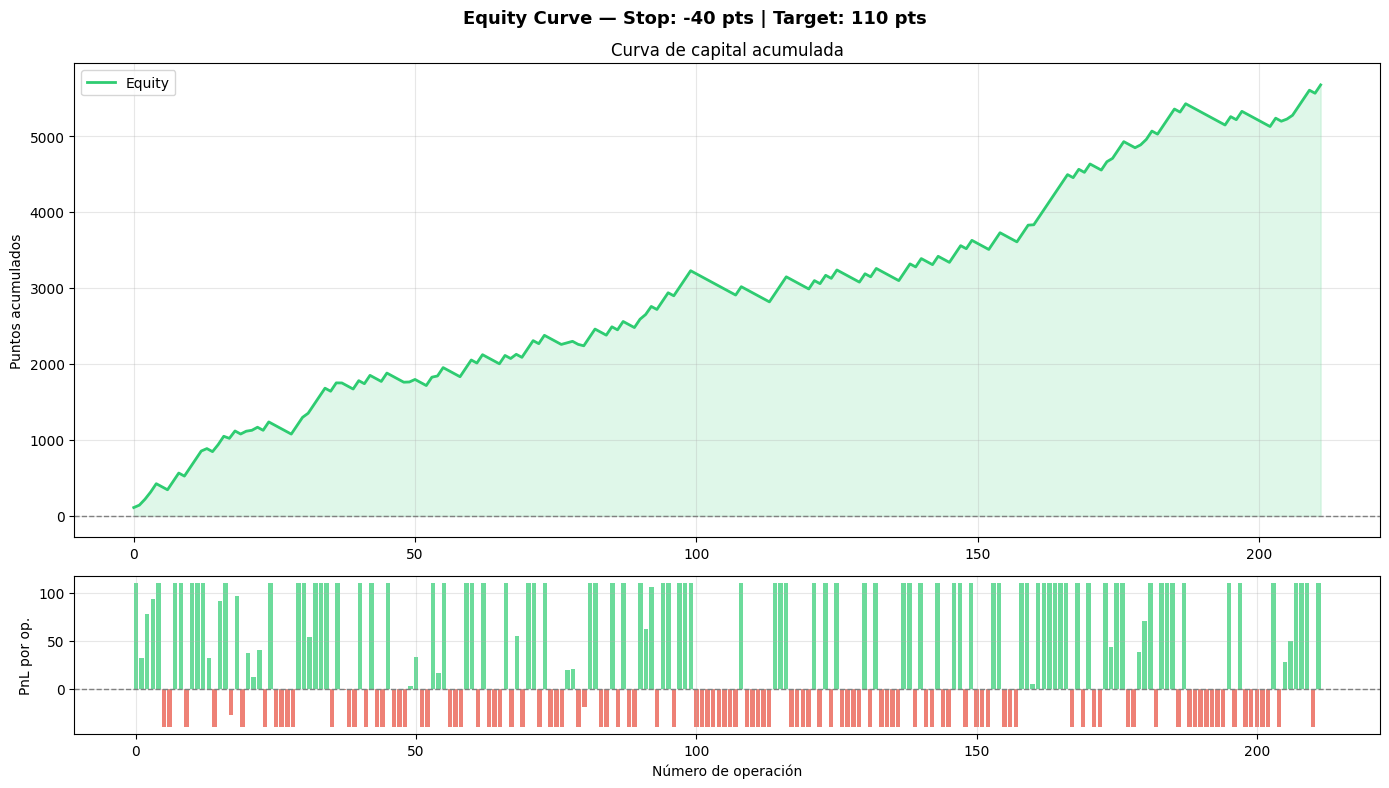

Gráfica guardada como 'equity_curve.png'


In [ ]:
# ─────────────────────────────────────────────
# EQUITY CURVE
# ─────────────────────────────────────────────

STOP_LOSS   = -40    # puntos
TAKE_PROFIT =  110   # puntos
def simular_operacion(row):
    mae = row['MAE']
    mfe = row['MFE']
    direction = row['direction']
    stop_tocado   = mae <= STOP_LOSS
    target_tocado = mfe >= TAKE_PROFIT

    if stop_tocado and target_tocado:
        # Ambos tocados, asumimos que el stop se toca primero (conservador)
        return STOP_LOSS
    elif target_tocado:
        return TAKE_PROFIT
    elif stop_tocado:
        return STOP_LOSS
    else:
        # Ni stop ni target — cierra al resultado del día
        return row['result']

df_eval['pnl'] = df_eval.apply(simular_operacion, axis=1)
df_eval['equity'] = df_eval['pnl'].cumsum()

# Métricas básicas
total_ops    = len(df_eval)
ganadoras    = (df_eval['pnl'] > 0).sum()
perdedoras   = (df_eval['pnl'] < 0).sum()
win_rate     = ganadoras / total_ops
pnl_total    = df_eval['pnl'].sum()
pnl_medio    = df_eval['pnl'].mean()
max_drawdown = (df_eval['equity'] - df_eval['equity'].cummax()).min()

print("=== RESULTADOS BACKTEST ===")
print(f"  Operaciones totales:  {total_ops}")
print(f"  Ganadoras:            {ganadoras} ({win_rate:.1%})")
print(f"  Perdedoras:           {perdedoras} ({1-win_rate:.1%})")
print(f"  PnL total:            {pnl_total:.1f} puntos")
print(f"  PnL medio/operación:  {pnl_medio:.1f} puntos")
print(f"  Max Drawdown:         {max_drawdown:.1f} puntos")
print(f"  Ratio beneficio/riesgo real: {abs(df_eval[df_eval['pnl']>0]['pnl'].mean()) / abs(df_eval[df_eval['pnl']<0]['pnl'].mean()):.2f}")

# ── Gráfica equity curve ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f'Equity Curve — Stop: {STOP_LOSS} pts | Target: {TAKE_PROFIT} pts',
             fontsize=13, fontweight='bold')

# Equity curve
ax1 = axes[0]
ax1.plot(df_eval['equity'].values, color='#2ecc71', lw=2, label='Equity')
ax1.fill_between(range(len(df_eval)), df_eval['equity'].values, 0,
                 where=df_eval['equity'].values >= 0,
                 alpha=0.15, color='#2ecc71')
ax1.fill_between(range(len(df_eval)), df_eval['equity'].values, 0,
                 where=df_eval['equity'].values < 0,
                 alpha=0.15, color='#e74c3c')
ax1.axhline(0, color='gray', linestyle='--', lw=1)
ax1.set_ylabel('Puntos acumulados')
ax1.set_title('Curva de capital acumulada')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PnL por operación
ax2 = axes[1]
colors_pnl = ['#2ecc71' if p > 0 else '#e74c3c' for p in df_eval['pnl']]
ax2.bar(range(len(df_eval)), df_eval['pnl'].values, color=colors_pnl, alpha=0.7)
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_ylabel('PnL por op.')
ax2.set_xlabel('Número de operación')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'equity_curve.png'")


=== TRAIN ===
  Operaciones: 813 | Win rate: 62.1%
  PnL total:   25674.0 pts | Medio: 31.6 pts/op
  Max DD:      -330.0 pts
  Ratio B/R:   1.99

=== TEST ===
  Operaciones: 212 | Win rate: 49.1%
  PnL total:   5673.0 pts | Medio: 26.8 pts/op
  Max DD:      -410.0 pts
  Ratio B/R:   2.43


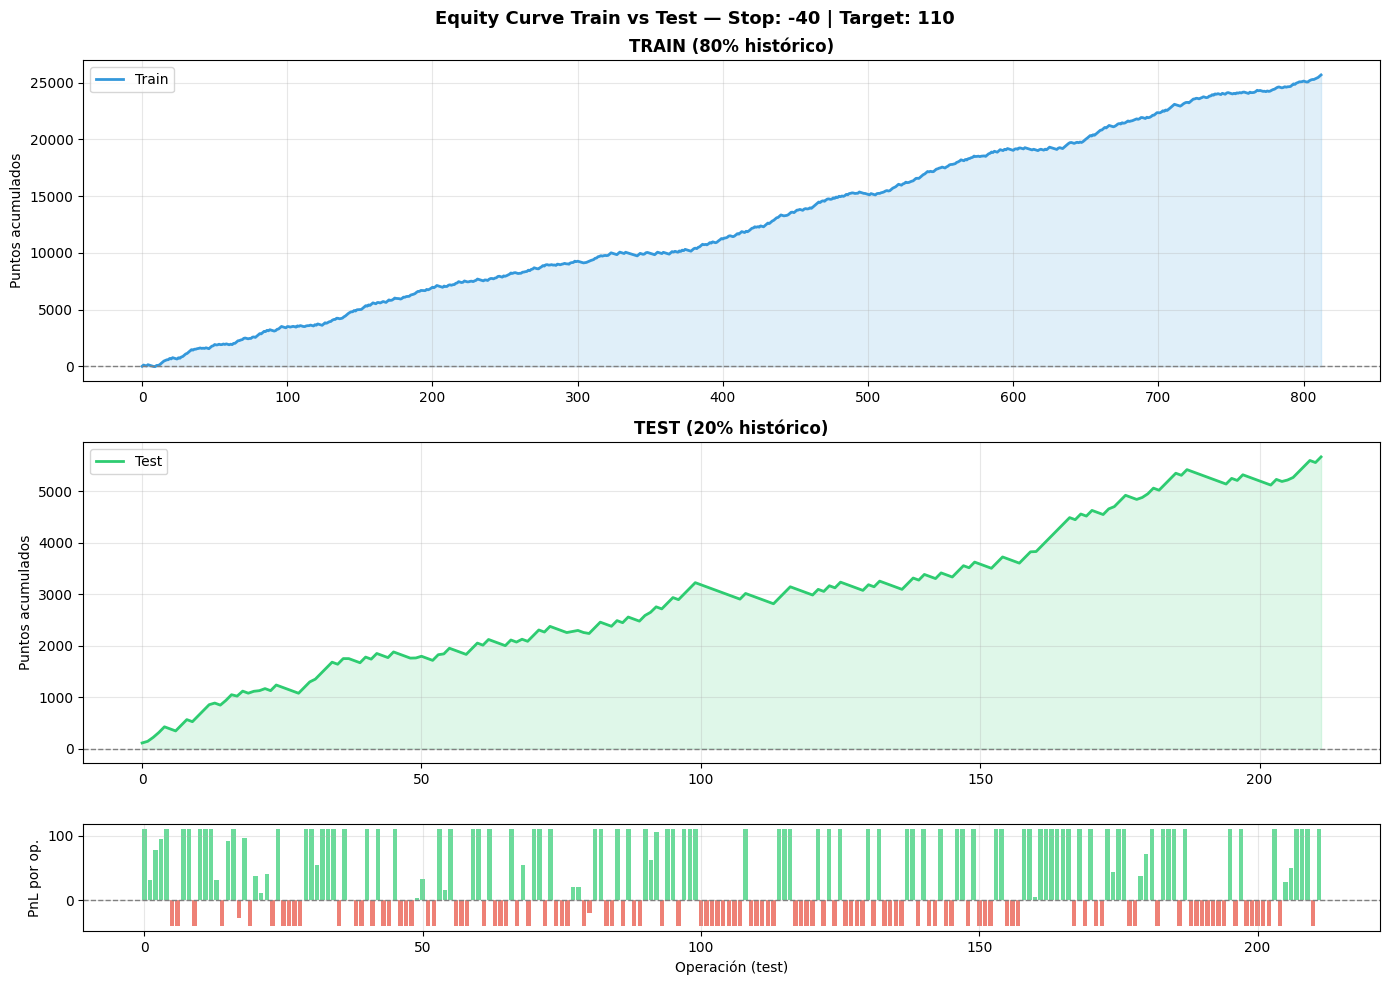

In [ ]:
# EQUITY CURVE — TRAIN vs TEST

STOP_LOSS   = -40
TAKE_PROFIT =  110

def simular_operacion(row):
    mae = row['MAE']
    mfe = row['MFE']
    stop_tocado   = mae <= STOP_LOSS
    target_tocado = mfe >= TAKE_PROFIT
    if stop_tocado and target_tocado:
        return STOP_LOSS
    elif target_tocado:
        return TAKE_PROFIT
    elif stop_tocado:
        return STOP_LOSS
    else:
        return row['result']

def construir_df_eval(indices, pred_labels_arr, probs_arr):
    """Construye df_eval para un conjunto de índices dado."""
    mask = pred_labels_arr != -1

    df_res = pd.DataFrame({
        'y_true':     y.iloc[indices],
        'prob_up':    probs_arr,
        'pred_label': pred_labels_arr
    }, index=y.iloc[indices].index)

    df_res = df_res[mask]

    df_prices = df_final.loc[df_res.index, ['D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']]
    df_res = df_res.join(df_prices)
    df_res['direction'] = df_res['pred_label'].map({1: 'long', 0: 'short'})

    df_res['MAE'] = np.where(
        df_res['direction'] == 'long',
        df_res['D_LOW']  - df_res['D_OPEN'],
        df_res['D_OPEN'] - df_res['D_HIGH']
    )
    df_res['MFE'] = np.where(
        df_res['direction'] == 'long',
        df_res['D_HIGH'] - df_res['D_OPEN'],
        df_res['D_OPEN'] - df_res['D_LOW']
    )
    df_res['result'] = np.where(
        df_res['direction'] == 'long',
        df_res['D_CLOSE'] - df_res['D_OPEN'],
        df_res['D_OPEN']  - df_res['D_CLOSE']
    )
    df_res['pnl']    = df_res.apply(simular_operacion, axis=1)
    df_res['equity'] = df_res['pnl'].cumsum()
    return df_res

#  Índices train y test
n = len(X)
train_size = int(n * 0.8)
train_idx = range(0, train_size)
test_idx  = range(train_size, n)

#  Predicciones sobre train
probs_train = model.predict_proba(X_train_scaled)[:, 1]
pred_labels_train = np.array([label_from_prob(p) for p in probs_train])

#  Construir df_eval para cada split
df_eval_train = construir_df_eval(train_idx, pred_labels_train, probs_train)
df_eval_test  = df_eval  # ya lo tienes calculado

#  Métricas comparadas
def metricas(df, nombre):
    total   = len(df)
    win     = (df['pnl'] > 0).sum()
    pnl     = df['pnl'].sum()
    dd      = (df['equity'] - df['equity'].cummax()).min()
    ratio   = abs(df[df['pnl']>0]['pnl'].mean()) / abs(df[df['pnl']<0]['pnl'].mean())
    print(f"\n=== {nombre} ===")
    print(f"  Operaciones: {total} | Win rate: {win/total:.1%}")
    print(f"  PnL total:   {pnl:.1f} pts | Medio: {pnl/total:.1f} pts/op")
    print(f"  Max DD:      {dd:.1f} pts")
    print(f"  Ratio B/R:   {ratio:.2f}")

metricas(df_eval_train, "TRAIN")
metricas(df_eval_test,  "TEST")

# Gráfica
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 3, 1]})
fig.suptitle(f'Equity Curve Train vs Test — Stop: {STOP_LOSS} | Target: {TAKE_PROFIT}',
             fontsize=13, fontweight='bold')

# Train
ax1 = axes[0]
ax1.plot(df_eval_train['equity'].values, color='#3498db', lw=2, label='Train')
ax1.fill_between(range(len(df_eval_train)), df_eval_train['equity'].values, 0,
                 alpha=0.15, color='#3498db')
ax1.axhline(0, color='gray', linestyle='--', lw=1)
ax1.set_title('TRAIN (80% histórico)', fontweight='bold')
ax1.set_ylabel('Puntos acumulados')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Test
ax2 = axes[1]
ax2.plot(df_eval_test['equity'].values, color='#2ecc71', lw=2, label='Test')
ax2.fill_between(range(len(df_eval_test)), df_eval_test['equity'].values, 0,
                 alpha=0.15, color='#2ecc71')
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_title('TEST (20% histórico)', fontweight='bold')
ax2.set_ylabel('Puntos acumulados')
ax2.legend(); ax2.grid(True, alpha=0.3)

# PnL barras test
ax3 = axes[2]
colors_pnl = ['#2ecc71' if p > 0 else '#e74c3c' for p in df_eval_test['pnl']]
ax3.bar(range(len(df_eval_test)), df_eval_test['pnl'].values, color=colors_pnl, alpha=0.7)
ax3.axhline(0, color='gray', linestyle='--', lw=1)
ax3.set_ylabel('PnL por op.'); ax3.set_xlabel('Operación (test)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()


=== TOP 10 por PnL total ===
 threshold_up  threshold_down  n_ops  win_rate  pnl_total  pnl_medio  max_drawdown  ratio_br
         0.55            0.35    307  0.527687       9263  30.172638          -380  2.369534
         0.55            0.45    376  0.489362       9224  24.531915          -375  2.332316
         0.55            0.40    335  0.510448       9169  27.370149          -420  2.336733
         0.60            0.35    264  0.534091       8505  32.215909          -340  2.427740
         0.60            0.45    333  0.489489       8466  25.423423          -346  2.377725
         0.60            0.40    292  0.513699       8411  28.804795          -380  2.386524
         0.55            0.30    275  0.534545       8405  30.563636          -330  2.347471
         0.60            0.30    232  0.543103       7647  32.961207          -290  2.409193
         0.55            0.25    251  0.525896       7356  29.306773          -290  2.337847
         0.65            0.35    221  0.5

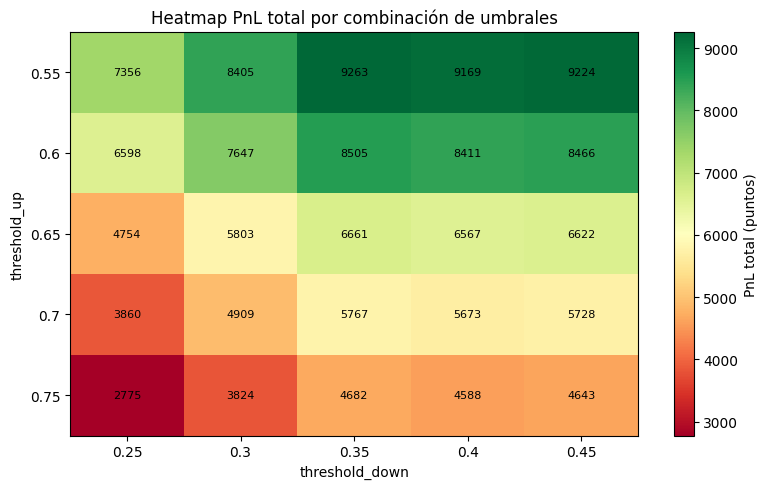

In [ ]:
# GRID SEARCH DE UMBRALES
import itertools

# Umbrales a probar
thresholds_up   = [0.55, 0.60, 0.65, 0.70, 0.75]
thresholds_down = [0.25, 0.30, 0.35, 0.40, 0.45]

resultados_umbrales = []

for t_up, t_down in itertools.product(thresholds_up, thresholds_down):
    if t_down >= t_up:
        continue  # no tiene sentido

    # Generar señales con estos umbrales
    labels = np.array([
        1 if p >= t_up else (0 if p <= t_down else -1)
        for p in probs
    ])

    mask = labels != -1
    if mask.sum() < 10:
        continue  # muy pocas operaciones, no es representativo

    # Construir df_eval temporal
    df_tmp = df_results[mask].copy()
    df_tmp['pred_label'] = labels[mask]
    df_prices = df_final.loc[y_test.index, ['D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']]
    df_tmp = df_tmp.join(df_prices)
    df_tmp['direction'] = df_tmp['pred_label'].map({1: 'long', 0: 'short'})

    df_tmp['MAE'] = np.where(
        df_tmp['direction'] == 'long',
        df_tmp['D_LOW']  - df_tmp['D_OPEN'],
        df_tmp['D_OPEN'] - df_tmp['D_HIGH']
    )
    df_tmp['MFE'] = np.where(
        df_tmp['direction'] == 'long',
        df_tmp['D_HIGH'] - df_tmp['D_OPEN'],
        df_tmp['D_OPEN'] - df_tmp['D_LOW']
    )
    df_tmp['result'] = np.where(
        df_tmp['direction'] == 'long',
        df_tmp['D_CLOSE'] - df_tmp['D_OPEN'],
        df_tmp['D_OPEN']  - df_tmp['D_CLOSE']
    )
    df_tmp['pnl'] = df_tmp.apply(simular_operacion, axis=1)

    total   = len(df_tmp)
    win     = (df_tmp['pnl'] > 0).sum()
    pnl     = df_tmp['pnl'].sum()
    equity  = df_tmp['pnl'].cumsum()
    dd      = (equity - equity.cummax()).min()
    wins    = df_tmp[df_tmp['pnl'] > 0]['pnl'].mean()
    losses  = df_tmp[df_tmp['pnl'] < 0]['pnl'].mean()
    ratio   = abs(wins / losses) if losses != 0 else 0

    resultados_umbrales.append({
        'threshold_up':   t_up,
        'threshold_down': t_down,
        'n_ops':          total,
        'win_rate':       win / total,
        'pnl_total':      pnl,
        'pnl_medio':      pnl / total,
        'max_drawdown':   dd,
        'ratio_br':       ratio
    })

df_umbrales = pd.DataFrame(resultados_umbrales)

# Ordenar por PnL total
print("=== TOP 10 por PnL total ===")
print(df_umbrales.sort_values('pnl_total', ascending=False).head(10).to_string(index=False))

print("\n=== TOP 10 por ratio B/R ===")
print(df_umbrales.sort_values('ratio_br', ascending=False).head(10).to_string(index=False))

print("\n=== TOP 10 por PnL medio/op ===")
print(df_umbrales.sort_values('pnl_medio', ascending=False).head(10).to_string(index=False))

# Heatmap PnL total
pivot_pnl = df_umbrales.pivot(index='threshold_up', columns='threshold_down', values='pnl_total')

plt.figure(figsize=(8, 5))
plt.imshow(pivot_pnl.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='PnL total (puntos)')
plt.xticks(range(len(pivot_pnl.columns)), pivot_pnl.columns)
plt.yticks(range(len(pivot_pnl.index)),   pivot_pnl.index)
plt.xlabel('threshold_down')
plt.ylabel('threshold_up')
plt.title('Heatmap PnL total por combinación de umbrales')
for i in range(len(pivot_pnl.index)):
    for j in range(len(pivot_pnl.columns)):
        val = pivot_pnl.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_umbrales.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# MODELO TARDE — Ventana 15:30–15:44

from datetime import time
df_open_mins_tarde = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(15, 44))
].copy()

df_open_mins_tarde = (
    df_open_mins_tarde
    .sort_values(['date', 'datetime'])
    .assign(min_id=lambda x: x.groupby('date').cumcount() + 1)
)

df_open_mins_tarde = df_open_mins_tarde.rename(columns={
    '<OPEN>': 'OPEN', '<HIGH>': 'HIGH',
    '<LOW>':  'LOW',  '<CLOSE>': 'CLOSE',
    '<VOL>':  'VOL',  '<OPENINT>': 'OPENINT'
})

cols = ['date', 'min_id', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
df_open_mins_tarde = df_open_mins_tarde[cols]

df_pivot_t = df_open_mins_tarde.pivot(
    index='date', columns='min_id',
    values=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
)
df_pivot_t.columns = [
    f"t{mid}_{var.lower()}"
    for var, mid in df_pivot_t.columns
]
df_pivot_t = df_pivot_t.reset_index()

df_final_t = df_final.merge(df_pivot_t, on='date', how='left')
df_final_t = df_final_t.sort_values('date').reset_index(drop=True)

open_cols_t  = [f't{i}_open'  for i in range(1, 16)]
close_cols_t = [f't{i}_close' for i in range(1, 16)]
high_cols_t  = [f't{i}_high'  for i in range(1, 16)]
low_cols_t   = [f't{i}_low'   for i in range(1, 16)]
vol_cols_t   = [f't{i}_vol'   for i in range(1, 16)]

df_final_t['vol_15m_total_t'] = df_final_t[vol_cols_t].sum(axis=1)
df_final_t['vol_15m_mean_t']  = df_final_t[vol_cols_t].mean(axis=1)
df_final_t['open_15m_t']      = df_final_t['t1_open']
df_final_t['close_15m_t']     = df_final_t['t15_close']
df_final_t['log_ret_15m_t']   = np.log(df_final_t['close_15m_t'] / df_final_t['open_15m_t'])
df_final_t['range_15m_t']     = df_final_t[high_cols_t].max(axis=1) - df_final_t[low_cols_t].min(axis=1)
df_final_t['dir_15m_t']       = np.sign(df_final_t['log_ret_15m_t'])

df_final_t = df_final_t.sort_values('date')
df_model_t = df_final_t.copy()
df_model_t['y'] = (df_final_t['log_ret'] > 0).astype(int)

cols_future_t = [
    'D_HIGH', 'D_LOW', 'D_CLOSE', 'D_VOL', 'D_OPENINT',
    'DISPLAY', 'BULLISH', 'CLOSE_OPEN', 'HINGE',
    'true_range', 'ATR_5', 'ATR_10', 'ATR_zscore',
    'vol_regime', 'MA5', 'MA20', 'trend_MA_cross',
    'prev_high', 'prev_low', 'log_ret', 'vol_15m_total', 'vol_15m_mean',
    'open_15m', 'close_15m', 'log_ret_15m', 'range_15m', 'dir_15m']
df_model_t = df_model_t.drop(
    columns=[c for c in cols_future_t if c in df_model_t.columns]
)

# Eliminar NaN y separar
df_model_t = df_model_t.dropna().copy()
X_t = df_model_t.drop(columns=['y', 'date'])
y_t = df_model_t['y']

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, shuffle=False
)

scaler_t = StandardScaler()
X_t_train_sc = scaler_t.fit_transform(X_t_train)
X_t_test_sc  = scaler_t.transform(X_t_test)

model_t = LogisticRegression(solver='lbfgs', max_iter=1000)
model_t.fit(X_t_train_sc, y_t_train)

probs_t = model_t.predict_proba(X_t_test_sc)[:, 1]

threshold_up_t   = 0.70
threshold_down_t = 0.40

pred_labels_t = np.array([
    1 if p >= threshold_up_t else (0 if p <= threshold_down_t else -1)
    for p in probs_t
])

df_results_t = pd.DataFrame({
    'y_true':     y_t_test,
    'prob_up':    probs_t,
    'pred_label': pred_labels_t
})

print("=== MODELO TARDE ===")
print(df_results_t['pred_label'].value_counts())

mask_t = pred_labels_t != -1
print("\nReporte solo predicciones claras:")
print(classification_report(
    y_t_test[mask_t], pred_labels_t[mask_t],
    target_names=['Baja (0)', 'Sube (1)']
))

=== MODELO TARDE ===
pred_label
 1    249
 0    140
-1     32
Name: count, dtype: int64

Reporte solo predicciones claras:
              precision    recall  f1-score   support

    Baja (0)       0.80      0.76      0.78       147
    Sube (1)       0.86      0.88      0.87       242

    accuracy                           0.84       389
   macro avg       0.83      0.82      0.83       389
weighted avg       0.84      0.84      0.84       389



tipo_dia
solo_tarde_long      143
doble_short           68
solo_tarde_short      67
contradiccion         56
doble_long            53
sin_señal             20
solo_manana_short     10
solo_manana_long       2
Name: count, dtype: int64

=== BACKTEST CONJUNTO ===
  Días en test:      419
  Días operados:     343
  Operaciones total: 464
  PnL total:         22648.0 pts
  Max Drawdown:      -360.0 pts

=== PnL POR TIPO DE DÍA ===
                   count   sum   mean
tipo_dia                             
contradiccion         56     0    0.0
doble_long            53  5356  101.1
doble_short           68  8754  128.7
sin_señal             20     0    0.0
solo_manana_long       2    70   35.0
solo_manana_short     10    -6   -0.6
solo_tarde_long      143  6634   46.4
solo_tarde_short      67  1840   27.5


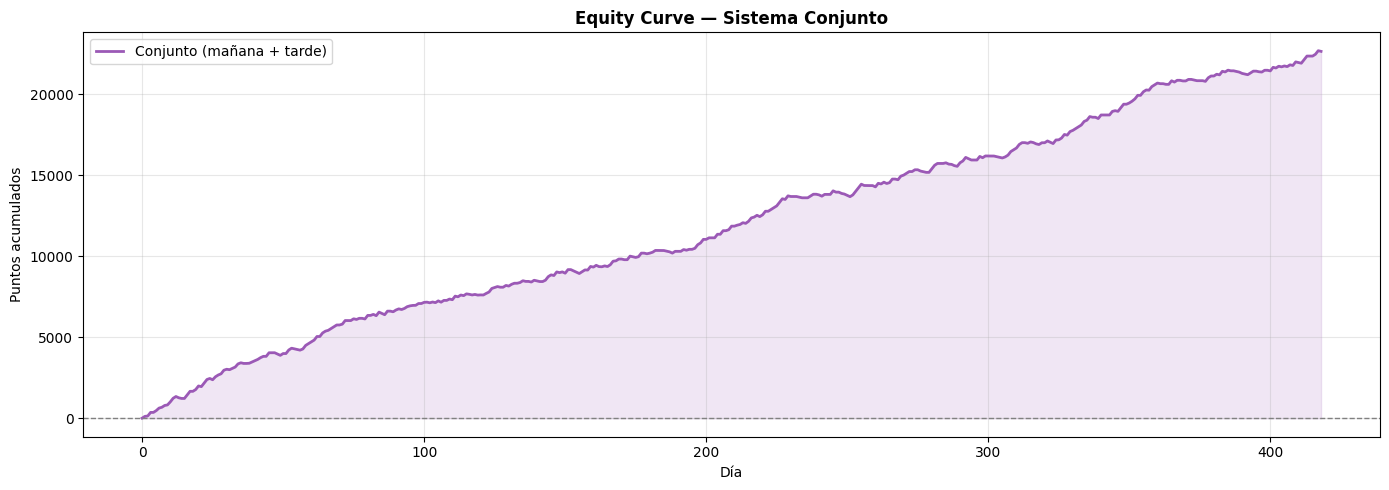

In [ ]:
# ANÁLISIS CONJUNTO — MODELO MAÑANA + MODELO TARDE

df_manana = pd.DataFrame({
    'y_true':     y_test,
    'prob_up':    probs,
    'pred_label': pred_labels,
    'modelo':     'manana'
}, index=y_test.index)

df_tarde = pd.DataFrame({
    'y_true':     y_t_test,
    'prob_up':    probs_t,
    'pred_label': pred_labels_t,
    'modelo':     'tarde'
}, index=y_t_test.index)

df_manana['date'] = df_final.loc[y_test.index, 'date'].values
df_tarde['date']  = df_final_t.loc[y_t_test.index, 'date'].values

df_conjunto = df_manana[['date', 'pred_label', 'prob_up']].rename(
    columns={'pred_label': 'pred_m', 'prob_up': 'prob_m'}
).merge(
    df_tarde[['date', 'pred_label', 'prob_up']].rename(
        columns={'pred_label': 'pred_t', 'prob_up': 'prob_t'}
    ),
    on='date', how='inner'
)

df_conjunto = df_conjunto.merge(
    df_final[['date', 'D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']],
    on='date', how='left'
)

# Clasificar el día
# Posibles combinaciones:
# ambos dan señal en la misma dirección → más convicción
# señales contrarias → no operar o gestionar con cuidado
# solo uno da señal → operar solo ese

def clasificar_dia(row):
    m = row['pred_m']   # -1, 0, 1
    t = row['pred_t']   # -1, 0, 1

    if m == -1 and t == -1:
        return 'sin_señal'
    elif m != -1 and t != -1:
        if m == t:
            return f'doble_{["short","long"][m]}'  # ambos de acuerdo
        else:
            return 'contradiccion'   # uno dice sube, otro baja
    elif m != -1:
        return f'solo_manana_{["short","long"][m]}'
    else:
        return f'solo_tarde_{["short","long"][t]}'

df_conjunto['tipo_dia'] = df_conjunto.apply(clasificar_dia, axis=1)
print(df_conjunto['tipo_dia'].value_counts())

STOP_LOSS   = -40
TAKE_PROFIT =  110

def pnl_operacion(direction, d_open, d_high, d_low, d_close):
    if direction == 'long':
        mae = d_low  - d_open
        mfe = d_high - d_open
        result = d_close - d_open
    else:
        mae = d_open - d_high
        mfe = d_open - d_low
        result = d_open - d_close

    if mae <= STOP_LOSS and mfe >= TAKE_PROFIT:
        return STOP_LOSS
    elif mfe >= TAKE_PROFIT:
        return TAKE_PROFIT
    elif mae <= STOP_LOSS:
        return STOP_LOSS
    else:
        return result

def simular_dia(row):
    tipo = row['tipo_dia']
    o, h, l, c = row['D_OPEN'], row['D_HIGH'], row['D_LOW'], row['D_CLOSE']
    pnl = 0
    n_ops = 0

    if 'doble_long' in tipo:
        pnl += pnl_operacion('long', o, h, l, c) * 2
        n_ops = 2
    elif 'doble_short' in tipo:
        pnl += pnl_operacion('short', o, h, l, c) * 2
        n_ops = 2
    elif 'solo_manana_long' in tipo or 'solo_tarde_long' in tipo:
        pnl += pnl_operacion('long', o, h, l, c)
        n_ops = 1
    elif 'solo_manana_short' in tipo or 'solo_tarde_short' in tipo:
        pnl += pnl_operacion('short', o, h, l, c)
        n_ops = 1

    return pd.Series({'pnl': pnl, 'n_ops': n_ops})

df_conjunto[['pnl', 'n_ops']] = df_conjunto.apply(simular_dia, axis=1)
df_conjunto['equity'] = df_conjunto['pnl'].cumsum()

total_ops = df_conjunto['n_ops'].sum()
dias_operados = (df_conjunto['n_ops'] > 0).sum()
win = (df_conjunto['pnl'] > 0).sum()
pnl_total = df_conjunto['pnl'].sum()
dd = (df_conjunto['equity'] - df_conjunto['equity'].cummax()).min()

print(f"\n=== BACKTEST CONJUNTO ===")
print(f"  Días en test:      {len(df_conjunto)}")
print(f"  Días operados:     {dias_operados}")
print(f"  Operaciones total: {int(total_ops)}")
print(f"  PnL total:         {pnl_total:.1f} pts")
print(f"  Max Drawdown:      {dd:.1f} pts")

print(f"\n=== PnL POR TIPO DE DÍA ===")
print(df_conjunto.groupby('tipo_dia')['pnl'].agg(['count','sum','mean']).round(1))

# Equity curve conjunta
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_conjunto['equity'].values, color='#9b59b6', lw=2, label='Conjunto (mañana + tarde)')
ax.fill_between(range(len(df_conjunto)), df_conjunto['equity'].values, 0,
                alpha=0.15, color='#9b59b6')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_title('Equity Curve — Sistema Conjunto', fontweight='bold')
ax.set_ylabel('Puntos acumulados')
ax.set_xlabel('Día')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('equity_conjunto.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib, json

# Guardar modelo de mañana
joblib.dump(model, '/content/drive/MyDrive/TFG/model_manana.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/TFG/scaler_manana.pkl')

# Guardar modelo de tarde
joblib.dump(model_t, '/content/drive/MyDrive/TFG/model_tarde.pkl')
joblib.dump(scaler_t, '/content/drive/MyDrive/TFG/scaler_tarde.pkl')

# Guardar columnas de cada modelo
feature_cols_manana = X.columns.tolist()
feature_cols_tarde  = X_t.columns.tolist()

with open('/content/drive/MyDrive/TFG/feature_cols_manana.json', 'w') as f:
    json.dump(feature_cols_manana, f)
with open('/content/drive/MyDrive/TFG/feature_cols_tarde.json', 'w') as f:
    json.dump(feature_cols_tarde, f)

print("Guardado")
print(f"Features mañana: {len(feature_cols_manana)}")
print(f"Features tarde:  {len(feature_cols_tarde)}")

✅ Guardado
Features mañana: 185
Features tarde:  267


=== BACKTEST CONJUNTO — CORREGIDO (sin fuga de información) ===
  Días en test: 419
  Días operados: 343
  Operaciones total: 464
  PnL total: 8526.0 pts
  Max Drawdown: -253.0 pts

=== PnL POR TIPO DE DÍA (corregido) ===
                   count     sum  mean
tipo_dia                              
contradiccion         56     0.0   0.0
doble_long            53  3373.0  63.6
doble_short           68  4266.0  62.7
sin_señal             20     0.0   0.0
solo_manana_long       2    70.0  35.0
solo_manana_short     10    -6.0  -0.6
solo_tarde_long      143   870.0   6.1
solo_tarde_short      67   -47.0  -0.7

=== COMPARATIVA ===
  PnL original (con fuga):   22648.0 pts
  PnL corregido (sin fuga):  8526.0 pts
  PnL solo mañana (2.6):     5673.0 pts


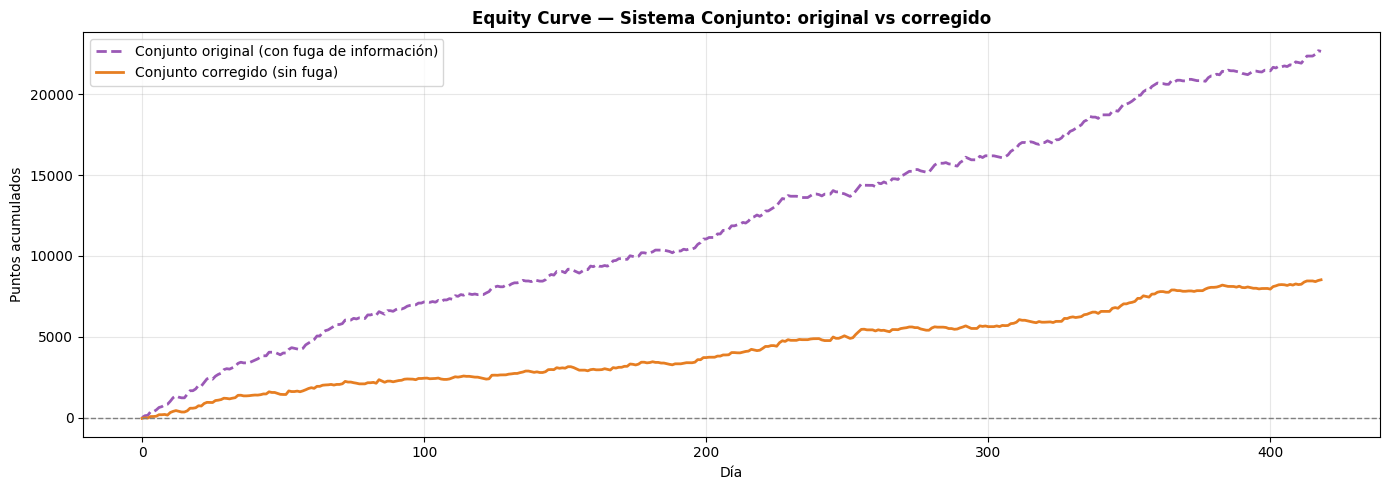


Gráfica guardada como 'equity_conjunto_corregido.png'


In [ ]:
# BACKTEST CONJUNTO — CORREGIDO

# La operación de TARDE solo puede usar el HIGH/LOW del tramo
# 15:30 -> 17:30 (cierre), no el D_HIGH/D_LOW del día completo,
# porque a las 15:30 el resto del día ya ha pasado o no existe aún.
#
# La operación de MAÑANA sí puede seguir usando D_HIGH/D_LOW del
# día completo, porque abre a las 9:15 y permanece viva el resto
# de la sesión.

from datetime import time

df_tarde_sesion = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(17, 30))
].copy()

rango_tarde = df_tarde_sesion.groupby('date').agg(
    OPEN_T=('OPEN', 'first'),
    HIGH_T=('HIGH', 'max'),
    LOW_T=('LOW', 'min'),
    CLOSE_T=('CLOSE', 'last')
).reset_index()

df_conjunto_v2 = df_conjunto.drop(columns=['pnl', 'n_ops', 'equity'], errors='ignore').copy()
df_conjunto_v2 = df_conjunto_v2.merge(rango_tarde, on='date', how='left')

# ── 3. Funciones de PnL separadas por ventana ────────────────
STOP_LOSS = -40
TAKE_PROFIT = 110

def pnl_manana(direction, d_open, d_high, d_low, d_close):
    """Operación de mañana: usa el rango de TODO el día (correcto,
    porque la operación permanece viva toda la sesión)."""
    if direction == 'long':
        mae = d_low - d_open
        mfe = d_high - d_open
        result = d_close - d_open
    else:
        mae = d_open - d_high
        mfe = d_open - d_low
        result = d_open - d_close

    if mae <= STOP_LOSS and mfe >= TAKE_PROFIT:
        return STOP_LOSS
    elif mfe >= TAKE_PROFIT:
        return TAKE_PROFIT
    elif mae <= STOP_LOSS:
        return STOP_LOSS
    else:
        return result

def pnl_tarde(direction, open_t, high_t, low_t, close_t):
    """Operación de tarde: usa SOLO el rango real 15:30 -> 17:30."""
    if pd.isna(open_t) or pd.isna(high_t) or pd.isna(low_t) or pd.isna(close_t):
        return 0.0

    if direction == 'long':
        mae = low_t - open_t
        mfe = high_t - open_t
        result = close_t - open_t
    else:
        mae = open_t - high_t
        mfe = open_t - low_t
        result = open_t - close_t

    if mae <= STOP_LOSS and mfe >= TAKE_PROFIT:
        return STOP_LOSS
    elif mfe >= TAKE_PROFIT:
        return TAKE_PROFIT
    elif mae <= STOP_LOSS:
        return STOP_LOSS
    else:
        return result

def simular_dia_v2(row):
    tipo = row['tipo_dia']
    o, h, l, c = row['D_OPEN'], row['D_HIGH'], row['D_LOW'], row['D_CLOSE']
    o_t, h_t, l_t, c_t = row['OPEN_T'], row['HIGH_T'], row['LOW_T'], row['CLOSE_T']

    pnl = 0.0
    n_ops = 0

    if tipo == 'doble_long':
        pnl += pnl_manana('long', o, h, l, c)
        pnl += pnl_tarde('long', o_t, h_t, l_t, c_t)
        n_ops = 2
    elif tipo == 'doble_short':
        pnl += pnl_manana('short', o, h, l, c)
        pnl += pnl_tarde('short', o_t, h_t, l_t, c_t)
        n_ops = 2
    elif tipo == 'solo_manana_long':
        pnl += pnl_manana('long', o, h, l, c)
        n_ops = 1
    elif tipo == 'solo_manana_short':
        pnl += pnl_manana('short', o, h, l, c)
        n_ops = 1
    elif tipo == 'solo_tarde_long':
        pnl += pnl_tarde('long', o_t, h_t, l_t, c_t)
        n_ops = 1
    elif tipo == 'solo_tarde_short':
        pnl += pnl_tarde('short', o_t, h_t, l_t, c_t)
        n_ops = 1

    return pd.Series({'pnl': pnl, 'n_ops': n_ops})

df_conjunto_v2[['pnl', 'n_ops']] = df_conjunto_v2.apply(simular_dia_v2, axis=1)
df_conjunto_v2['equity'] = df_conjunto_v2['pnl'].cumsum()

total_ops_v2 = df_conjunto_v2['n_ops'].sum()
dias_operados_v2 = (df_conjunto_v2['n_ops'] > 0).sum()
pnl_total_v2 = df_conjunto_v2['pnl'].sum()
dd_v2 = (df_conjunto_v2['equity'] - df_conjunto_v2['equity'].cummax()).min()

print("=== BACKTEST CONJUNTO — CORREGIDO (sin fuga de información) ===")
print(f"  Días en test: {len(df_conjunto_v2)}")
print(f"  Días operados: {dias_operados_v2}")
print(f"  Operaciones total: {int(total_ops_v2)}")
print(f"  PnL total: {pnl_total_v2:.1f} pts")
print(f"  Max Drawdown: {dd_v2:.1f} pts")

print("\n=== PnL POR TIPO DE DÍA (corregido) ===")
print(df_conjunto_v2.groupby('tipo_dia')['pnl'].agg(['count', 'sum', 'mean']).round(1))

print("\n=== COMPARATIVA ===")
print(f"  PnL original (con fuga):   {df_conjunto['pnl'].sum():.1f} pts")
print(f"  PnL corregido (sin fuga):  {pnl_total_v2:.1f} pts")
print(f"  PnL solo mañana (2.6):     {df_eval['pnl'].sum():.1f} pts")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_conjunto['equity'].values, color='#9b59b6', lw=2, linestyle='--',
        label='Conjunto original (con fuga de información)')
ax.plot(df_conjunto_v2['equity'].values, color='#e67e22', lw=2,
        label='Conjunto corregido (sin fuga)')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_title('Equity Curve — Sistema Conjunto: original vs corregido', fontweight='bold')
ax.set_ylabel('Puntos acumulados')
ax.set_xlabel('Día')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('equity_conjunto_corregido.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada como 'equity_conjunto_corregido.png'")

In [ ]:
print("=== MAÑANA ===")
print(feature_cols_manana)
print("\n=== TARDE ===")
print(feature_cols_tarde)

=== MAÑANA ===
['D_OPEN', 'm1_open', 'm2_open', 'm3_open', 'm4_open', 'm5_open', 'm6_open', 'm7_open', 'm8_open', 'm9_open', 'm10_open', 'm11_open', 'm12_open', 'm13_open', 'm14_open', 'm15_open', 'm1_high', 'm2_high', 'm3_high', 'm4_high', 'm5_high', 'm6_high', 'm7_high', 'm8_high', 'm9_high', 'm10_high', 'm11_high', 'm12_high', 'm13_high', 'm14_high', 'm15_high', 'm1_low', 'm2_low', 'm3_low', 'm4_low', 'm5_low', 'm6_low', 'm7_low', 'm8_low', 'm9_low', 'm10_low', 'm11_low', 'm12_low', 'm13_low', 'm14_low', 'm15_low', 'm1_close', 'm2_close', 'm3_close', 'm4_close', 'm5_close', 'm6_close', 'm7_close', 'm8_close', 'm9_close', 'm10_close', 'm11_close', 'm12_close', 'm13_close', 'm14_close', 'm15_close', 'm1_vol', 'm2_vol', 'm3_vol', 'm4_vol', 'm5_vol', 'm6_vol', 'm7_vol', 'm8_vol', 'm9_vol', 'm10_vol', 'm11_vol', 'm12_vol', 'm13_vol', 'm14_vol', 'm15_vol', 'year', 'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open', 'p_close_open_mean', 'p_close_open_sd', '

=== MAÑANA (referencia, sesión completa 9:15-17:30) ===
  MAE p50: -39.0 | MFE p50: 108.5
  MFE >= 110 pts: 49.5% de las operaciones

=== TARDE — usando D_HIGH/D_LOW del día completo (SOBREESTIMA) ===
  MAE p50: -27.0 | MFE p50: 116.0
  MFE >= 110 pts: 53.7% de las operaciones

=== TARDE — usando solo el tramo real 15:30-17:30 ===
  MAE_real p50: -23.0 | MFE_real p50: 36.0
  MFE_real >= 110 pts: 1.8% de las operaciones
  MFE_real >= 40 pts (cubre solo el stop simétrico): 46.3% de las operaciones


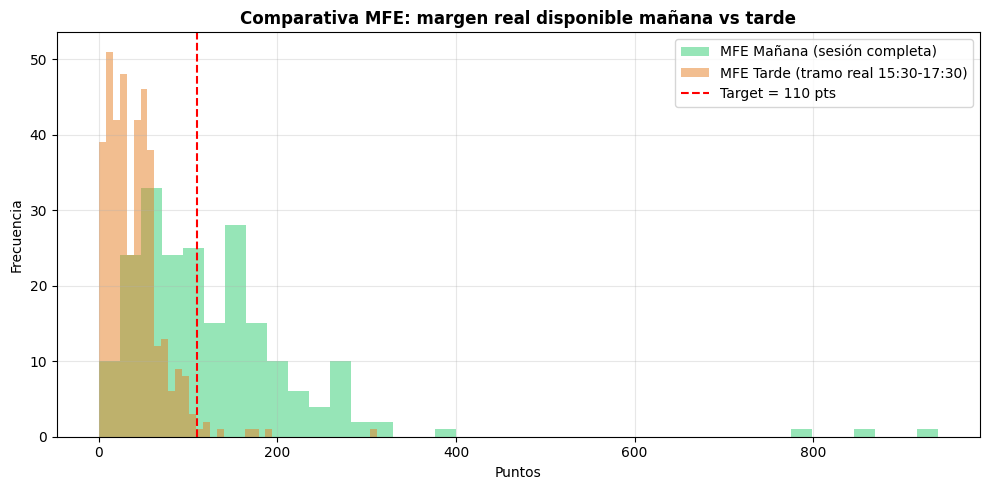


Gráfica guardada como 'comparativa_mfe_manana_tarde.png'


In [ ]:
# VALIDACIÓN: MARGEN TEMPORAL TARDE VS MAÑANA

# Objetivo: comprobar si el MAE/MFE de las operaciones de TARDE
# es estructuralmente más pequeño que el de MAÑANA, por disponer
# de menos tiempo de sesión hasta el cierre (15:30 -> 17:30
# frente a 9:15 -> 17:30).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mask_t = pred_labels_t != -1
df_eval_t = pd.DataFrame({
    'y_true': y_t_test,
    'prob_up': probs_t,
    'pred_label': pred_labels_t
}, index=y_t_test.index)
df_eval_t = df_eval_t[mask_t]

df_prices_t = df_final_t.loc[df_eval_t.index, ['D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']]
df_eval_t = df_eval_t.join(df_prices_t)

df_eval_t['direction'] = df_eval_t['pred_label'].map({1: 'long', 0: 'short'})

# MAE/MFE se calculan igual que en mañana, sobre el HIGH/LOW
# de TODO el día (D_HIGH, D_LOW), porque es lo que tenemos en el dataset.
# Esto en realidad sobreestima el margen real de tarde, ya que D_HIGH/D_LOW
# pueden haberse marcado antes de las 15:30. Por eso el experimento real
# tiene que limitarse al rango horario correcto (ver paso 2).

df_eval_t['MAE'] = np.where(
    df_eval_t['direction'] == 'long',
    df_eval_t['D_LOW'] - df_eval_t['D_OPEN'],
    df_eval_t['D_OPEN'] - df_eval_t['D_HIGH']
)
df_eval_t['MFE'] = np.where(
    df_eval_t['direction'] == 'long',
    df_eval_t['D_HIGH'] - df_eval_t['D_OPEN'],
    df_eval_t['D_OPEN'] - df_eval_t['D_LOW']
)

# MAE/MFE limitado al tramo real 15:30 -> 17:30
# Necesitamos el HIGH/LOW de la sesión desde las 15:30 hasta
# el cierre (17:30), usando el open de la ventana de tarde (t1_open)
# como referencia, no el D_OPEN del día completo.

from datetime import time

df_tarde_sesion = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(17, 30))
].copy()

rango_tarde = df_tarde_sesion.groupby('date').agg(
    OPEN_T=('OPEN', 'first'),
    HIGH_T=('HIGH', 'max'),
    LOW_T=('LOW', 'min'),
    CLOSE_T=('CLOSE', 'last')
).reset_index()

df_eval_t2 = df_eval_t[['direction']].copy()
df_eval_t2 = df_eval_t2.join(
    df_final_t.loc[df_eval_t2.index, ['date']]
)
df_eval_t2 = df_eval_t2.merge(rango_tarde, on='date', how='left').set_index(df_eval_t2.index if False else df_eval_t2.index)

# Recalcular MAE/MFE reales del tramo 15:30-17:30
df_eval_t2['MAE_real'] = np.where(
    df_eval_t2['direction'] == 'long',
    df_eval_t2['LOW_T'] - df_eval_t2['OPEN_T'],
    df_eval_t2['OPEN_T'] - df_eval_t2['HIGH_T']
)
df_eval_t2['MFE_real'] = np.where(
    df_eval_t2['direction'] == 'long',
    df_eval_t2['HIGH_T'] - df_eval_t2['OPEN_T'],
    df_eval_t2['OPEN_T'] - df_eval_t2['LOW_T']
)

# Comparativa de medianas y percentiles
print("=== MAÑANA (referencia, sesión completa 9:15-17:30) ===")
print(f"  MAE p50: {np.percentile(df_eval['MAE'], 50):.1f} | MFE p50: {np.percentile(df_eval['MFE'], 50):.1f}")
print(f"  MFE >= 110 pts: {(df_eval['MFE'] >= 110).mean():.1%} de las operaciones")

print("\n=== TARDE — usando D_HIGH/D_LOW del día completo (SOBREESTIMA) ===")
print(f"  MAE p50: {np.percentile(df_eval_t['MAE'], 50):.1f} | MFE p50: {np.percentile(df_eval_t['MFE'], 50):.1f}")
print(f"  MFE >= 110 pts: {(df_eval_t['MFE'] >= 110).mean():.1%} de las operaciones")

print("\n=== TARDE — usando solo el tramo real 15:30-17:30 ===")
print(f"  MAE_real p50: {np.percentile(df_eval_t2['MAE_real'].dropna(), 50):.1f} | MFE_real p50: {np.percentile(df_eval_t2['MFE_real'].dropna(), 50):.1f}")
print(f"  MFE_real >= 110 pts: {(df_eval_t2['MFE_real'] >= 110).mean():.1%} de las operaciones")
print(f"  MFE_real >= 40 pts (cubre solo el stop simétrico): {(df_eval_t2['MFE_real'] >= 40).mean():.1%} de las operaciones")

#  Gráfica comparativa de distribuciones MFE
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_eval['MFE'], bins=40, alpha=0.5, label='MFE Mañana (sesión completa)', color='#2ecc71')
ax.hist(df_eval_t2['MFE_real'].dropna(), bins=40, alpha=0.5, label='MFE Tarde (tramo real 15:30-17:30)', color='#e67e22')
ax.axvline(110, color='red', linestyle='--', lw=1.5, label='Target = 110 pts')
ax.set_title('Comparativa MFE: margen real disponible mañana vs tarde', fontweight='bold')
ax.set_xlabel('Puntos')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparativa_mfe_manana_tarde.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada como 'comparativa_mfe_manana_tarde.png'")

=== BACKTEST CONJUNTO — CORREGIDO (sin fuga de información) ===
  Días en test: 419
  Días operados: 343
  Operaciones total: 464
  PnL total: 8526.0 pts
  Max Drawdown: -253.0 pts

=== PnL POR TIPO DE DÍA (corregido) ===
                   count     sum  mean
tipo_dia                              
contradiccion         56     0.0   0.0
doble_long            53  3373.0  63.6
doble_short           68  4266.0  62.7
sin_señal             20     0.0   0.0
solo_manana_long       2    70.0  35.0
solo_manana_short     10    -6.0  -0.6
solo_tarde_long      143   870.0   6.1
solo_tarde_short      67   -47.0  -0.7

=== COMPARATIVA ===
  PnL original (con fuga):   22648.0 pts
  PnL corregido (sin fuga):  8526.0 pts
  PnL solo mañana (2.6):     5673.0 pts
=== RANGOS DE FECHAS DE CADA SERIE (para detectar el desalineamiento) ===
  Solo mañana:        2024-03-27  ->  2026-01-15  (212 ops)
  Conjunto original:  2024-03-21  ->  2026-01-16  (419 días)
  Conjunto corregido: 2024-03-21  ->  2026-01-16  (

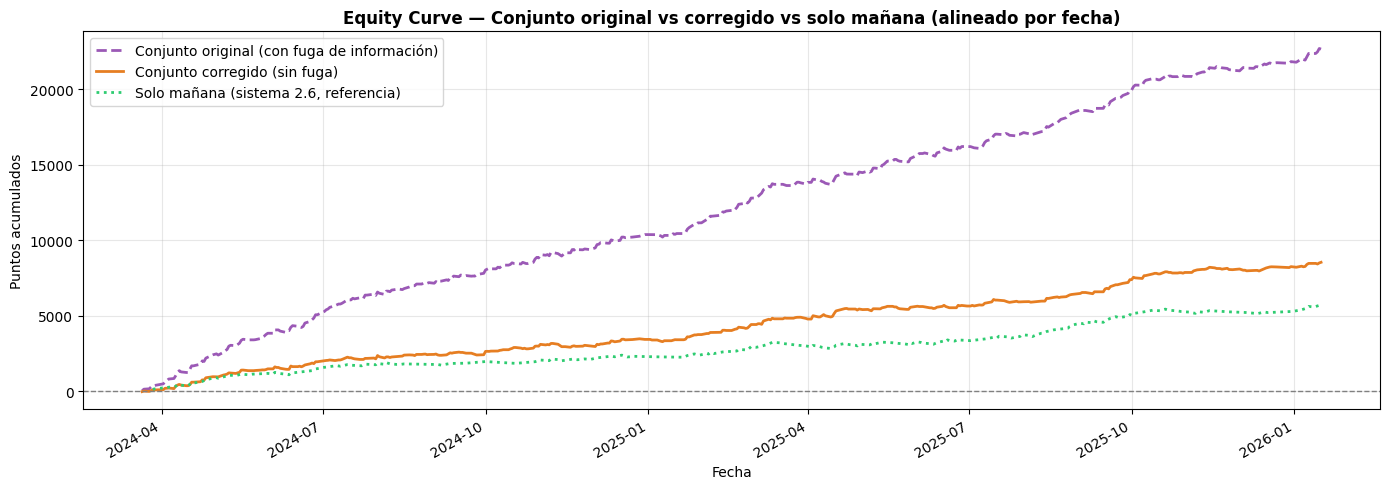


Gráfica guardada como 'equity_conjunto_corregido.png'

=== RESUMEN FINAL ===
  Conjunto con fuga (engañoso):  22648.0 pts  | 419 días
  Conjunto corregido (real):     8526.0 pts  | 419 días
  Solo mañana (2.6, referencia): 5673.0 pts  | 212 operaciones

  -> Sobreestimación introducida por la fuga: 14122.0 pts


In [ ]:
# BACKTEST CONJUNTO — CORREGIDO

# La operación de tarde solo puede usar el HIGH/LOW del tramo
# 15:30 -> 17:30 (cierre), no el D_HIGH/D_LOW del día completo,
# porque a las 15:30 el resto del día ya ha pasado o no existe aún.
#
# La operación de MAÑANA sí puede seguir usando D_HIGH/D_LOW del
# día completo, porque abre a las 9:15 y permanece viva el resto
# de la sesión.

from datetime import time

# ── 0. Reconstruir 'time' por si df_min no lo tiene en este punto ──
if 'time' not in df_min.columns or 'date' not in df_min.columns:
    df_min['date_str'] = df_min['<DTYYYYMMDD>'].astype(str)
    df_min['time_str'] = df_min['<TIME>'].astype(str).str.zfill(6)
    df_min['datetime'] = pd.to_datetime(
        df_min['date_str'] + df_min['time_str'], format='%Y%m%d%H%M%S'
    )
    df_min['date'] = df_min['datetime'].dt.normalize()
    df_min['time'] = df_min['datetime'].dt.time
    df_min = df_min.rename(columns={
        '<OPEN>': 'OPEN', '<HIGH>': 'HIGH',
        '<LOW>': 'LOW', '<CLOSE>': 'CLOSE',
        '<VOL>': 'VOL', '<OPENINT>': 'OPENINT'
    })

df_tarde_sesion = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(17, 30))
].copy()

rango_tarde = df_tarde_sesion.groupby('date').agg(
    OPEN_T=('OPEN', 'first'),
    HIGH_T=('HIGH', 'max'),
    LOW_T=('LOW', 'min'),
    CLOSE_T=('CLOSE', 'last')
).reset_index()

df_conjunto_v2 = df_conjunto.drop(columns=['pnl', 'n_ops', 'equity'], errors='ignore').copy()
df_conjunto_v2 = df_conjunto_v2.merge(rango_tarde, on='date', how='left')

STOP_LOSS = -40
TAKE_PROFIT = 110

def pnl_manana(direction, d_open, d_high, d_low, d_close):
    """Operación de mañana: usa el rango de TODO el día (correcto,
    porque la operación permanece viva toda la sesión)."""
    if direction == 'long':
        mae = d_low - d_open
        mfe = d_high - d_open
        result = d_close - d_open
    else:
        mae = d_open - d_high
        mfe = d_open - d_low
        result = d_open - d_close

    if mae <= STOP_LOSS and mfe >= TAKE_PROFIT:
        return STOP_LOSS
    elif mfe >= TAKE_PROFIT:
        return TAKE_PROFIT
    elif mae <= STOP_LOSS:
        return STOP_LOSS
    else:
        return result

def pnl_tarde(direction, open_t, high_t, low_t, close_t):
    """Operación de tarde: usa SOLO el rango real 15:30 -> 17:30."""
    if pd.isna(open_t) or pd.isna(high_t) or pd.isna(low_t) or pd.isna(close_t):
        return 0.0

    if direction == 'long':
        mae = low_t - open_t
        mfe = high_t - open_t
        result = close_t - open_t
    else:
        mae = open_t - high_t
        mfe = open_t - low_t
        result = open_t - close_t

    if mae <= STOP_LOSS and mfe >= TAKE_PROFIT:
        return STOP_LOSS
    elif mfe >= TAKE_PROFIT:
        return TAKE_PROFIT
    elif mae <= STOP_LOSS:
        return STOP_LOSS
    else:
        return result

def simular_dia_v2(row):
    tipo = row['tipo_dia']
    o, h, l, c = row['D_OPEN'], row['D_HIGH'], row['D_LOW'], row['D_CLOSE']
    o_t, h_t, l_t, c_t = row['OPEN_T'], row['HIGH_T'], row['LOW_T'], row['CLOSE_T']

    pnl = 0.0
    n_ops = 0

    if tipo == 'doble_long':
        pnl += pnl_manana('long', o, h, l, c)
        pnl += pnl_tarde('long', o_t, h_t, l_t, c_t)
        n_ops = 2
    elif tipo == 'doble_short':
        pnl += pnl_manana('short', o, h, l, c)
        pnl += pnl_tarde('short', o_t, h_t, l_t, c_t)
        n_ops = 2
    elif tipo == 'solo_manana_long':
        pnl += pnl_manana('long', o, h, l, c)
        n_ops = 1
    elif tipo == 'solo_manana_short':
        pnl += pnl_manana('short', o, h, l, c)
        n_ops = 1
    elif tipo == 'solo_tarde_long':
        pnl += pnl_tarde('long', o_t, h_t, l_t, c_t)
        n_ops = 1
    elif tipo == 'solo_tarde_short':
        pnl += pnl_tarde('short', o_t, h_t, l_t, c_t)
        n_ops = 1

    return pd.Series({'pnl': pnl, 'n_ops': n_ops})

df_conjunto_v2[['pnl', 'n_ops']] = df_conjunto_v2.apply(simular_dia_v2, axis=1)
df_conjunto_v2['equity'] = df_conjunto_v2['pnl'].cumsum()

total_ops_v2 = df_conjunto_v2['n_ops'].sum()
dias_operados_v2 = (df_conjunto_v2['n_ops'] > 0).sum()
pnl_total_v2 = df_conjunto_v2['pnl'].sum()
dd_v2 = (df_conjunto_v2['equity'] - df_conjunto_v2['equity'].cummax()).min()

print("=== BACKTEST CONJUNTO — CORREGIDO (sin fuga de información) ===")
print(f"  Días en test: {len(df_conjunto_v2)}")
print(f"  Días operados: {dias_operados_v2}")
print(f"  Operaciones total: {int(total_ops_v2)}")
print(f"  PnL total: {pnl_total_v2:.1f} pts")
print(f"  Max Drawdown: {dd_v2:.1f} pts")

print("\n=== PnL POR TIPO DE DÍA (corregido) ===")
print(df_conjunto_v2.groupby('tipo_dia')['pnl'].agg(['count', 'sum', 'mean']).round(1))

print("\n=== COMPARATIVA ===")
print(f"  PnL original (con fuga):   {df_conjunto['pnl'].sum():.1f} pts")
print(f"  PnL corregido (sin fuga):  {pnl_total_v2:.1f} pts")
print(f"  PnL solo mañana (2.6):     {df_eval['pnl'].sum():.1f} pts")

serie_manana = pd.Series(
    df_eval['equity'].values,
    index=df_final.loc[df_eval.index, 'date'].values
).sort_index()

serie_conjunto_orig = pd.Series(
    df_conjunto['equity'].values,
    index=df_conjunto['date'].values
).sort_index()

serie_conjunto_v2 = pd.Series(
    df_conjunto_v2['equity'].values,
    index=df_conjunto_v2['date'].values
).sort_index()

print("=== RANGOS DE FECHAS DE CADA SERIE (para detectar el desalineamiento) ===")
print(f"  Solo mañana:        {serie_manana.index.min().date()}  ->  {serie_manana.index.max().date()}  ({len(serie_manana)} ops)")
print(f"  Conjunto original:  {serie_conjunto_orig.index.min().date()}  ->  {serie_conjunto_orig.index.max().date()}  ({len(serie_conjunto_orig)} días)")
print(f"  Conjunto corregido: {serie_conjunto_v2.index.min().date()}  ->  {serie_conjunto_v2.index.max().date()}  ({len(serie_conjunto_v2)} días)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_conjunto_orig.index, serie_conjunto_orig.values, color='#9b59b6', lw=2, linestyle='--',
        label='Conjunto original (con fuga de información)')
ax.plot(serie_conjunto_v2.index, serie_conjunto_v2.values, color='#e67e22', lw=2,
        label='Conjunto corregido (sin fuga)')
ax.plot(serie_manana.index, serie_manana.values, color='#2ecc71', lw=2, linestyle=':',
        label='Solo mañana (sistema 2.6, referencia)')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_title('Equity Curve — Conjunto original vs corregido vs solo mañana (alineado por fecha)', fontweight='bold')
ax.set_ylabel('Puntos acumulados')
ax.set_xlabel('Fecha')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('equity_conjunto_corregido.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada como 'equity_conjunto_corregido.png'")

print("\n=== RESUMEN FINAL ===")
print(f"  Conjunto con fuga (engañoso):  {df_conjunto['pnl'].sum():.1f} pts  | {len(df_conjunto)} días")
print(f"  Conjunto corregido (real):     {pnl_total_v2:.1f} pts  | {len(df_conjunto_v2)} días")
print(f"  Solo mañana (2.6, referencia): {df_eval['pnl'].sum():.1f} pts  | {len(df_eval)} operaciones")
print(f"\n  -> Sobreestimación introducida por la fuga: {df_conjunto['pnl'].sum() - pnl_total_v2:.1f} pts")